<a href="https://colab.research.google.com/github/anupriya-babbar/Churn_Prediction/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn xgboost imbalanced-learn pandas matplotlib seaborn --quiet

In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [ ]:
# # Install Kaggle API client
# !pip install kaggle --upgrade --quiet

# # Securely store your API key in Colab Secrets
# from google.colab import userdata

# import os
# os.environ['KAGGLE_USERNAME'] = userdata.get('anupriyababbar')
# os.environ['KAGGLE_KEY'] = userdata.get('Kaggle_Api_Key')

# print("✅ Kaggle API configured.")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bvmadduluri/wsdm-kkbox")

print("Path to dataset files:", path)

100%|██████████| 703M/703M [00:08<00:00, 91.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bvmadduluri/wsdm-kkbox/versions/1


In [ ]:
import os

path = "/root/.cache/kagglehub/datasets/bvmadduluri/wsdm-kkbox/versions/1"

for f in os.listdir(path):
    size_mb = os.path.getsize(os.path.join(path, f)) / 1e6
    print(f"  {f:<40} {size_mb:.1f} MB")

  train.csv                                971.7 MB
  song_extra_info.csv                      181.0 MB
  members.csv                              2.5 MB
  songs.csv                                221.8 MB
  test.csv                                 347.8 MB


In [ ]:
# ============================================================
# STEP 1C: Load KKBOX files (adapted to actual available files)
# ============================================================
path = "/root/.cache/kagglehub/datasets/bvmadduluri/wsdm-kkbox/versions/1"

# ── 1. Peek at train.csv first (971MB — don't load blind) ──
print("=== TRAIN.CSV — First look (100 rows sample) ===")
train_sample = pd.read_csv(f"{path}/train.csv", nrows=100)
print(f"Columns : {train_sample.columns.tolist()}")
print(f"Dtypes  :\n{train_sample.dtypes}")
print(f"\nSample:\n{train_sample.head(3)}")

=== TRAIN.CSV — First look (100 rows sample) ===
Columns : ['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'target']
Dtypes  :
msno                  object
song_id               object
source_system_tab     object
source_screen_name    object
source_type           object
target                 int64
dtype: object

Sample:
                                           msno  \
0  FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=   
1  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   
2  Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=   

                                        song_id source_system_tab  \
0  BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=           explore   
1  bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=        my library   
2  JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=        my library   

    source_screen_name      source_type  target  
0              Explore  online-playlist       1  
1  Local playlist more   local-playlist       1  
2  Local playl

In [ ]:
# ── 2. Now load full train with optimized dtypes ──
print("\n⏳ Loading full train.csv (971MB, may take ~1–2 min)...")

train = pd.read_csv(f"{path}/train.csv",
                    dtype={'msno'              : 'category',
                           'song_id'           : 'category',
                           'source_system_tab' : 'category',
                           'source_screen_name': 'category',
                           'source_type'       : 'category',
                           'target'            : 'int8'})   # churn label

print(f"✅ train.csv        → {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"   Churn rate       → {train['target'].mean()*100:.2f}%")
print(f"   Unique users     → {train['msno'].nunique():,}")
print(f"   Unique songs     → {train['song_id'].nunique():,}")


⏳ Loading full train.csv (971MB, may take ~1–2 min)...
✅ train.csv        → 7,377,418 rows × 6 cols
   Churn rate       → 50.35%
   Unique users     → 30,755
   Unique songs     → 359,966


In [ ]:
train.head(10)

,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1
5,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3Hg5kugV1S0wzEVLAEfqjIV5UHzb7bCrdBRQlGygLvU=,explore,Explore,online-playlist,1
6,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,VkILU0H1h3NMmk9MQrXouNudGk5n8Ls5cqRRuBxeTh4=,my library,Local playlist more,local-playlist,1
7,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,bPIvRTzfHxH5LgHrStll+tYwSQNVV8PySgA3M1PfTgc=,explore,Explore,online-playlist,1
8,uHqAtShXTRXju5GE8ri3ITsVFepPf8jUoCF7ffNOuqE=,/bU6IRSK+YNlNbaTkxo7bhsb2EDLPrnksdX3ggcZNhI=,my library,Local playlist more,local-library,1
9,uHqAtShXTRXju5GE8ri3ITsVFepPf8jUoCF7ffNOuqE=,EbI7xoNxI+3QSsiHxL13zBdgHIJOwa3srHd7cDcnJ0g=,my library,Local playlist more,local-library,1


In [ ]:
train.columns

Index(['msno', 'song_id', 'source_system_tab', 'source_screen_name',
       'source_type', 'target'],
      dtype='object')

In [ ]:


train = pd.read_csv(f"{path}/train.csv",
                    dtype={
                        'msno'               : 'category',
                        'song_id'            : 'category',
                        'source_system_tab'  : 'category',
                        'source_screen_name' : 'category',
                        'source_type'        : 'category',
                        'target'             : 'int8'
                    })

print(f"✅ Done!")
print(f"\n   Rows            : {train.shape[0]:,}")
print(f"   Columns         : {train.shape[1]}")
print(f"   Unique users    : {train['msno'].nunique():,}")
print(f"   Unique songs    : {train['song_id'].nunique():,}")
print(f"   Churn rate      : {train['target'].mean()*100:.2f}%")
print(f"   Memory usage    : {train.memory_usage(deep=True).sum()/1e6:.1f} MB")

✅ Done!

   Rows            : 7,377,418
   Columns         : 6
   Unique users    : 30,755
   Unique songs    : 359,966
   Churn rate      : 50.35%
   Memory usage    : 119.6 MB


In [ ]:
 print("⏳ Loading members.csv...")

members = pd.read_csv(f"{path}/members.csv",
                      dtype={
                          'msno'          : 'category',
                          'city'          : 'int8',
                          'bd'            : 'int32',   # raw age field — has outliers
                          'gender'        : 'category',
                          'registered_via': 'int8'
                      })

print(f"✅ Done!")
print(f"\n   Rows            : {members.shape[0]:,}")
print(f"   Columns         : {members.shape[1]}")
print(f"   Column names    : {members.columns.tolist()}")
print(f"   Memory usage    : {members.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\n--- Sample ---")
print(members.head(5))

print(f"\n--- Missing values ---")
print(members.isnull().sum())

print(f"\n--- Gender breakdown ---")
print(members['gender'].value_counts(dropna=False))

print(f"\n--- City distribution ---")
print(members['city'].value_counts().head(10))

print(f"\n--- Registration method ---")
print(members['registered_via'].value_counts())

print(f"\n--- Age (bd) quick stats ---")
print(members['bd'].describe())

⏳ Loading members.csv...
✅ Done!

   Rows            : 34,403
   Columns         : 7
   Column names    : ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'expiration_date']
   Memory usage    : 5.2 MB

--- Sample ---
                                           msno  city  bd gender  \
0  XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=     1   0    NaN   
1  UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=     1   0    NaN   
2  D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=     1   0    NaN   
3  mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=     1   0    NaN   
4  q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=     1   0    NaN   

   registered_via  registration_init_time  expiration_date  
0               7                20110820         20170920  
1               7                20150628         20170622  
2               4                20160411         20170712  
3               9                20150906         20150907  
4               4                2017012

In [ ]:
print("⏳ Loading songs.csv...")

songs = pd.read_csv(f"{path}/songs.csv",
                    dtype={
                        'song_id'     : 'category',
                        'song_length' : 'float32',
                        'genre_ids'   : 'category',
                        'artist_name' : 'category',
                        'composer'    : 'category',
                        'lyricist'    : 'category',
                        'language'    : 'float32'
                    })

print(f"✅ Done!")
print(f"\n   Rows            : {songs.shape[0]:,}")
print(f"   Columns         : {songs.shape[1]}")
print(f"   Column names    : {songs.columns.tolist()}")
print(f"   Memory usage    : {songs.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n--- Sample ---")
print(songs.head(5))

print(f"\n--- Missing values ---")
print(songs.isnull().sum())

print(f"\n--- Song length stats (ms) ---")
print(songs['song_length'].describe())

print(f"\n--- Top 10 languages ---")
print(songs['language'].value_counts().head(10))

print(f"\n--- Unique artists ---")
print(f"   Total unique artists : {songs['artist_name'].nunique():,}")

⏳ Loading songs.csv...
✅ Done!

   Rows            : 2,296,320
   Columns         : 7
   Column names    : ['song_id', 'song_length', 'genre_ids', 'artist_name', 'composer', 'lyricist', 'language']
   Memory usage    : 416.7 MB

--- Sample ---
                                        song_id  song_length genre_ids  \
0  CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=     247640.0       465   
1  o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=     197328.0       444   
2  DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=     231781.0       465   
3  dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=     273554.0       465   
4  W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=     140329.0       726   

        artist_name                            composer     lyricist  language  
0  張信哲 (Jeff Chang)                                  董貞          何啟弘       3.0  
1         BLACKPINK  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM        TEDDY      31.0  
2      SUPER JUNIOR                                 NaN          NaN

In [ ]:
print("⏳ Loading song_extra_info.csv...")

song_extra = pd.read_csv(f"{path}/song_extra_info.csv",
                          dtype={
                              'song_id' : 'category',
                              'name'    : 'category',
                              'isrc'    : 'category'
                          })

print(f"✅ Done!")
print(f"\n   Rows            : {song_extra.shape[0]:,}")
print(f"   Columns         : {song_extra.shape[1]}")
print(f"   Column names    : {song_extra.columns.tolist()}")
print(f"   Memory usage    : {song_extra.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n--- Sample ---")
print(song_extra.head(5))

print(f"\n--- Missing values ---")
print(song_extra.isnull().sum())

print(f"\n--- ISRC country codes (first 2 chars = country) ---")
# ISRC format: CC-XXX-YY-NNNNN where CC = country code
song_extra['isrc_country'] = song_extra['isrc'].astype(str).str[:2]
print(song_extra['isrc_country'].value_counts().head(10))


⏳ Loading song_extra_info.csv...
✅ Done!

   Rows            : 2,295,971
   Columns         : 3
   Column names    : ['song_id', 'name', 'isrc']
   Memory usage    : 619.2 MB

--- Sample ---
                                        song_id             name          isrc
0  LP7pLJoJFBvyuUwvu+oLzjT+bI+UeBPURCecJsX1jjs=               我們  TWUM71200043
1  ClazTFnk6r0Bnuie44bocdNMM3rdlrq0bCGAsGUWcHE=  Let Me Love You  QMZSY1600015
2  u2ja/bZE3zhCGxvbbOB3zOoUjx27u40cf5g09UXMoKQ=              原諒我  TWA530887303
3  92Fqsy0+p6+RHe2EoLKjHahORHR1Kq1TBJoClW9v+Ts=          Classic  USSM11301446
4  0QFmz/+rJy1Q56C1DuYqT9hKKqi5TUqx0sN0IwvoHrw=             愛投羅網  TWA471306001

--- Missing values ---
song_id         0
name            3
isrc       136548
dtype: int64

--- ISRC country codes (first 2 chars = country) ---
isrc_country
US    651830
GB    310782
DE    194045
FR    148459
na    136548
TC    104693
JP    100264
QM     87529
TW     77432
IT     69400
Name: count, dtype: int64


In [ ]:
# Before merging, always verify that join keys overlap correctly
# A bad join silently creates nulls or explodes row counts

print("=== JOIN KEY AUDIT ===")

print(f"\n[train ↔ members] on msno")
train_users   = set(train['msno'].unique())
members_users = set(members['msno'].unique())
print(f"   Users in train          : {len(train_users):,}")
print(f"   Users in members        : {len(members_users):,}")
print(f"   Overlap (can join)      : {len(train_users & members_users):,}")
print(f"   In train NOT in members : {len(train_users - members_users):,}")
print(f"   In members NOT in train : {len(members_users - train_users):,}")

print(f"\n[train ↔ songs] on song_id")
train_songs = set(train['song_id'].unique())
songs_songs = set(songs['song_id'].unique())
print(f"   Songs in train          : {len(train_songs):,}")
print(f"   Songs in songs.csv      : {len(songs_songs):,}")
print(f"   Overlap (can join)      : {len(train_songs & songs_songs):,}")
print(f"   In train NOT in songs   : {len(train_songs - songs_songs):,}")

print(f"\n[songs ↔ song_extra] on song_id")
extra_songs = set(song_extra['song_id'].unique())
print(f"   Songs in songs.csv      : {len(songs_songs):,}")
print(f"   Songs in song_extra     : {len(extra_songs):,}")
print(f"   Overlap (can join)      : {len(songs_songs & extra_songs):,}")
print(f"   In songs NOT in extra   : {len(songs_songs - extra_songs):,}")

=== JOIN KEY AUDIT ===

[train ↔ members] on msno
   Users in train          : 30,755
   Users in members        : 34,403
   Overlap (can join)      : 30,755
   In train NOT in members : 0
   In members NOT in train : 3,648

[train ↔ songs] on song_id
   Songs in train          : 359,966
   Songs in songs.csv      : 2,296,320
   Overlap (can join)      : 359,914
   In train NOT in songs   : 52

[songs ↔ song_extra] on song_id
   Songs in songs.csv      : 2,296,320
   Songs in song_extra     : 2,295,971
   Overlap (can join)      : 2,295,422
   In songs NOT in extra   : 898


In [ ]:
# ============================================================
# STEP: Merge all 4 tables → one master dataframe
# We do this in stages so we can verify row counts at each step
# ============================================================

print("=== MERGING TABLES ===")
print(f"Starting rows (train) : {len(train):,}")

# ── Stage 1: train + members (user demographics) ──
# left join — keep all train rows, attach member info
df = train.merge(members, on='msno', how='left')
print(f"\nAfter train + members : {len(df):,} rows  "
      f"(expected {len(train):,} — {'✅ OK' if len(df)==len(train) else '❌ ROW COUNT CHANGED'})")

# ── Stage 2: + songs (song metadata) ──
# left join — keep all rows, attach song info where available
df = df.merge(songs, on='song_id', how='left')
print(f"After + songs         : {len(df):,} rows  "
      f"(expected {len(train):,} — {'✅ OK' if len(df)==len(train) else '❌ ROW COUNT CHANGED'})")

# ── Stage 3: + song_extra (ISRC country) ──
# left join — only need song_id + isrc_country column
df = df.merge(song_extra[['song_id', 'isrc_country']], on='song_id', how='left')
print(f"After + song_extra    : {len(df):,} rows  "
      f"(expected {len(train):,} — {'✅ OK' if len(df)==len(train) else '❌ ROW COUNT CHANGED'})")

# ── Final shape ──
print(f"\n=== MASTER DATAFRAME ===")
print(f"   Rows     : {df.shape[0]:,}")
print(f"   Columns  : {df.shape[1]}")
print(f"   Columns  : {df.columns.tolist()}")
print(f"   Memory   : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n--- Sample row ---")
df.head(3)

=== MERGING TABLES ===
Starting rows (train) : 7,377,418

After train + members : 7,377,418 rows  (expected 7,377,418 — ✅ OK)
After + songs         : 7,377,418 rows  (expected 7,377,418 — ✅ OK)
After + song_extra    : 7,377,418 rows  (expected 7,377,418 — ✅ OK)

=== MASTER DATAFRAME ===
   Rows     : 7,377,418
   Columns  : 19
   Columns  : ['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'target', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'expiration_date', 'song_length', 'genre_ids', 'artist_name', 'composer', 'lyricist', 'language', 'isrc_country']
   Memory   : 2185.7 MB

--- Sample row ---


,msno,song_id,source_system_tab,source_screen_name,source_type,target,city,bd,gender,registered_via,registration_init_time,expiration_date,song_length,genre_ids,artist_name,composer,lyricist,language,isrc_country
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,1,0,NaN,7,20120102,20171005,206471.0,359,Bastille,Dan Smith| Mark Crew,NaN,52.0,GB
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,13,24,female,9,20110525,20170911,284584.0,1259,Various Artists,NaN,NaN,52.0,US
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,13,24,female,9,20110525,20170911,225396.0,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,NaN,52.0,US


In [ ]:
# ============================================================
# Full health check on the merged master dataframe
# ============================================================

print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'Missing Count': missing,
                      'Missing %': missing_pct})
print(audit[audit['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print(f"\n=== TARGET DISTRIBUTION ===")
vc = df['target'].value_counts()
print(f"   Churned (1)  : {vc[1]:,}  ({vc[1]/len(df)*100:.2f}%)")
print(f"   Stayed  (0)  : {vc[0]:,}  ({vc[0]/len(df)*100:.2f}%)")

print(f"\n=== CATEGORICAL COLUMNS — unique value counts ===")
cat_cols = ['source_system_tab', 'source_screen_name',
            'source_type', 'gender', 'isrc_country',
            'registered_via', 'city']
for col in cat_cols:
    print(f"   {col:<25} : {df[col].nunique():>5} unique  "
          f"| {df[col].isnull().sum():,} missing")

print(f"\n=== NUMERIC COLUMNS — quick stats ===")
num_cols = ['song_length', 'language', 'bd']
print(df[num_cols].describe().round(2))

print(f"\n=== COLUMNS TO DROP (too sparse to be useful) ===")
drop_candidates = audit[audit['Missing %'] > 50].index.tolist()
print(f"   {drop_candidates}")
print(f"   Dropping these will save ~"
      f"{df[drop_candidates].memory_usage(deep=True).sum()/1e6:.0f} MB")

=== MISSING VALUES ===
                    Missing Count  Missing %
lyricist                  3178812      43.09
gender                    2961479      40.14
composer                  1675706      22.71
source_screen_name         414804       5.62
genre_ids                  118455       1.61
source_system_tab           24849       0.34
source_type                 21539       0.29
isrc_country                 1455       0.02
song_length                   114       0.00
artist_name                   114       0.00
language                      150       0.00

=== TARGET DISTRIBUTION ===
   Churned (1)  : 3,714,656  (50.35%)
   Stayed  (0)  : 3,662,762  (49.65%)

=== CATEGORICAL COLUMNS — unique value counts ===
   source_system_tab         :     8 unique  | 24,849 missing
   source_screen_name        :    20 unique  | 414,804 missing
   source_type               :    12 unique  | 21,539 missing
   gender                    :     2 unique  | 2,961,479 missing
   isrc_country              

In [ ]:
# ============================================================
# STEP: Clean master dataframe
# We do one operation at a time with memory checks
# ============================================================

print(f"Memory before cleaning : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Shape before cleaning  : {df.shape}")

# ── 1. Drop lyricist — 43% missing, no salvageable signal ──
df.drop(columns=['lyricist'], inplace=True)
print(f"\n✅ Dropped lyricist")

# ── 2. Convert composer → binary has_composer flag ──
# Instead of storing 1M+ category strings, store 0/1
df['has_composer'] = df['composer'].notnull().astype('int8')
df.drop(columns=['composer'], inplace=True)
print(f"✅ composer → has_composer (0/1 flag)")

# ── 3. Clean age (bd) — keep only realistic values ──
# Valid age range: 7 to 70. Everything outside → NaN
df['bd'] = df['bd'].where(df['bd'].between(7, 70), other=np.nan)
print(f"✅ bd cleaned — valid range 7–70, rest → NaN")
print(f"   Valid age rows remaining : {df['bd'].notnull().sum():,} "
      f"({df['bd'].notnull().sum()/len(df)*100:.1f}%)")

# ── 4. Fill gender NaN → 'unknown' ──
df['gender'] = df['gender'].astype(str)
df['gender'] = df['gender'].replace('nan', 'unknown')
print(f"✅ gender NaN → 'unknown'")
print(f"   Gender breakdown:\n{df['gender'].value_counts()}")

# ── 5. Fill source columns NaN → 'unknown' ──
for col in ['source_system_tab', 'source_screen_name', 'source_type']:
    df[col] = df[col].astype(str).replace('nan', 'unknown')
print(f"✅ source columns NaN → 'unknown'")

# ── 6. Fix ISRC country — merge TC + TW → TW ──
df['isrc_country'] = df['isrc_country'].astype(str)
df['isrc_country'] = df['isrc_country'].replace({'TC': 'TW', 'nan': 'Unknown'})
print(f"✅ isrc_country: TC → TW, nan → Unknown")

# ── 7. Handle language -1 → treat as separate category ──
# -1 means unknown/instrumental — valid signal, not a mistake
df['language'] = df['language'].fillna(-1).astype('int8')
print(f"✅ language: NaN → -1 (unknown category)")

# ── 8. Fill tiny gaps in song_length & artist_name ──
df['song_length'] = df['song_length'].fillna(df['song_length'].median())
df['artist_name'] = df['artist_name'].fillna('Unknown')
df['genre_ids']   = df['genre_ids'].astype(str).replace('nan', 'Unknown')
print(f"✅ song_length, artist_name, genre_ids gaps filled")

# ── 9. Parse date columns ──
df['registration_init_time'] = pd.to_datetime(
    df['registration_init_time'].astype(str), format='%Y%m%d', errors='coerce')
df['expiration_date'] = pd.to_datetime(
    df['expiration_date'].astype(str), format='%Y%m%d', errors='coerce')
print(f"✅ Date columns parsed to datetime")

# ── Final check ──
print(f"\n=== AFTER CLEANING ===")
print(f"Shape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if remaining_missing.empty:
    print("Missing: ✅ None remaining")
else:
    print(f"Missing still:\n{remaining_missing}")

Memory before cleaning : 2185.7 MB
Shape before cleaning  : (7377418, 19)

✅ Dropped lyricist
✅ composer → has_composer (0/1 flag)
✅ bd cleaned — valid range 7–70, rest → NaN
   Valid age rows remaining : 4,425,502 (60.0%)
✅ gender NaN → 'unknown'
   Gender breakdown:
gender
unknown    2961479
male       2297623
female     2118316
Name: count, dtype: int64
✅ source columns NaN → 'unknown'
✅ isrc_country: TC → TW, nan → Unknown
✅ language: NaN → -1 (unknown category)
✅ song_length, artist_name, genre_ids gaps filled
✅ Date columns parsed to datetime

=== AFTER CLEANING ===
Shape  : (7377418, 18)
Memory : 4195.4 MB
Missing still:
bd    2951916
dtype: int64


In [ ]:
# ============================================================
# STEP: Fix memory — convert string columns back to category
# astype(str) in Cell 9 inflated RAM from 2.1GB → 4.1GB
# ============================================================

print(f"Memory before fix : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

# All columns that are currently stored as plain str → convert to category
str_to_category = [
    'msno',
    'song_id',
    'source_system_tab',
    'source_screen_name',
    'source_type',
    'gender',
    'isrc_country',
    'artist_name',
    'genre_ids'
]

for col in str_to_category:
    df[col] = df[col].astype('category')
    print(f"   ✅ {col:<25} → category  "
          f"({df[col].nunique():,} unique values)")

# song_length can be float32 instead of float64
df['song_length'] = df['song_length'].astype('float32')

# language is already int8 — confirm
print(f"\n=== MEMORY AFTER FIX ===")
print(f"Memory after fix  : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n=== FINAL COLUMN DTYPES ===")
print(df.dtypes)

Memory before fix : 4195.4 MB
   ✅ msno                      → category  (30,755 unique values)
   ✅ song_id                   → category  (359,966 unique values)
   ✅ source_system_tab         → category  (9 unique values)
   ✅ source_screen_name        → category  (21 unique values)
   ✅ source_type               → category  (13 unique values)
   ✅ gender                    → category  (3 unique values)
   ✅ isrc_country              → category  (110 unique values)
   ✅ artist_name               → category  (40,583 unique values)
   ✅ genre_ids                 → category  (573 unique values)

=== MEMORY AFTER FIX ===
Memory after fix  : 439.4 MB

=== FINAL COLUMN DTYPES ===
msno                            category
song_id                         category
source_system_tab               category
source_screen_name              category
source_type                     category
target                              int8
city                                int8
bd                          

In [ ]:
# ============================================================
# STEP: Collapse 7.3M event rows → 30,755 user rows
# This is the core feature engineering step
# Every column here is a potential churn predictor
# ============================================================

print("⏳ Aggregating 7.3M rows → user level...")
print("   (This may take 1–2 mins)\n")

# ── 1. Engineer date features BEFORE aggregating ──
# These are computed at event level using datetime columns
ref_date = df['expiration_date'].max()  # use latest expiry as reference

df['tenure_days'] = (
    df['expiration_date'] - df['registration_init_time']
).dt.days

df['days_to_expiry'] = (
    df['expiration_date'] - ref_date
).dt.days

print("✅ tenure_days and days_to_expiry computed")

# ── 2. Aggregate all features per user ──
user_df = df.groupby('msno', observed=True).agg(

    # --- Target (same for all rows of a user) ---
    target                  = ('target', 'first'),

    # --- Listening volume ---
    total_plays             = ('song_id', 'count'),
    unique_songs            = ('song_id', 'nunique'),

    # --- Source behavior ---
    # What % of plays came from each tab
    pct_my_library          = ('source_system_tab',
                               lambda x: (x == 'my library').mean()),
    pct_discover            = ('source_system_tab',
                               lambda x: (x == 'discover').mean()),
    pct_search              = ('source_system_tab',
                               lambda x: (x == 'search').mean()),

    # What % of plays came from each source type
    pct_local_library       = ('source_type',
                               lambda x: (x == 'local-library').mean()),
    pct_online_playlist     = ('source_type',
                               lambda x: (x == 'online-playlist').mean()),
    pct_radio               = ('source_type',
                               lambda x: (x == 'radio').mean()),

    # --- Song characteristics ---
    avg_song_length         = ('song_length', 'mean'),
    pct_has_composer        = ('has_composer', 'mean'),

    # --- Content language behavior ---
    pct_mandarin            = ('language',
                               lambda x: (x == 3).mean()),
    pct_unknown_lang        = ('language',
                               lambda x: (x == -1).mean()),
    pct_english             = ('language',
                               lambda x: (x == 31).mean()),

    # --- Song origin ---
    pct_us_songs            = ('isrc_country',
                               lambda x: (x == 'US').mean()),
    pct_tw_songs            = ('isrc_country',
                               lambda x: (x == 'TW').mean()),

    # --- User demographics (same for all rows of a user) ---
    city                    = ('city', 'first'),
    gender                  = ('gender', 'first'),
    registered_via          = ('registered_via', 'first'),
    age                     = ('bd', 'median'),

    # --- Subscription info ---
    tenure_days             = ('tenure_days', 'first'),
    days_to_expiry          = ('days_to_expiry', 'first'),

).reset_index()

print(f"✅ Aggregation complete!")
print(f"\n   Rows    : {user_df.shape[0]:,}  (one per user)")
print(f"   Columns : {user_df.shape[1]}")
print(f"   Memory  : {user_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\n--- Churn rate preserved ---")
print(f"   {user_df['target'].mean()*100:.2f}%  "
      f"(should match original 50.35%)")
print(f"\n--- Sample ---")
print(user_df.head(3))


⏳ Aggregating 7.3M rows → user level...
   (This may take 1–2 mins)

✅ tenure_days and days_to_expiry computed
✅ Aggregation complete!

   Rows    : 30,755  (one per user)
   Columns : 23
   Memory  : 8.4 MB

--- Churn rate preserved ---
   59.39%  (should match original 50.35%)

--- Sample ---
                                           msno  target  total_plays  \
0  ++5wYjoMgQHoRuD3GbbvmphZbBBwymzv5Q4l8sywtuU=       0          589   
1  ++AH7m/EQ4iKe6wSlfO/xXAJx50p+fCeTyF90GoE9Pg=       0          220   
2  ++e+jsxuQ8UEnmW40od9Rq3rW7+wAum4wooXyZTKJpk=       1          108   

   unique_songs  pct_my_library  pct_discover  pct_search  pct_local_library  \
0           589        0.845501      0.154499         0.0           0.458404   
1           220        0.995455      0.004545         0.0           0.922727   
2           108        0.990741      0.009259         0.0           0.000000   

   pct_online_playlist  pct_radio  ...  pct_unknown_lang  pct_english  \
0             0.08149

In [ ]:
df.head(2)

,msno,song_id,source_system_tab,source_screen_name,source_type,target,city,bd,gender,registered_via,registration_init_time,expiration_date,song_length,genre_ids,artist_name,language,isrc_country,has_composer,tenure_days,days_to_expiry
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,1,NaN,unknown,7,2012-01-02,2017-10-05,206471.0,359,Bastille,52,GB,1,2103,-1108
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,13,24.0,female,9,2011-05-25,2017-09-11,284584.0,1259,Various Artists,52,US,0,2301,-1132


In [ ]:
# ============================================================
# STEP: Diagnose why churn rate shifted after aggregation
# ============================================================

print("=== TARGET CONSISTENCY CHECK ===")

# For each user, count how many distinct target values they have
target_consistency = df.groupby('msno', observed=True)['target'].nunique()

print(f"\n   Users with only 1 target value  : "
      f"{(target_consistency == 1).sum():,}")
print(f"   Users with mixed target values  : "
      f"{(target_consistency > 1).sum():,}")

# Look at users with mixed targets
mixed_users = target_consistency[target_consistency > 1].index
print(f"\n--- Sample mixed-target user ---")
sample_user = mixed_users[0]
print(df[df['msno'] == sample_user][['msno', 'target']].value_counts())

# Check what 'first' picked vs majority vote
print(f"\n=== CHURN RATE COMPARISON ===")
print(f"   Event-level (original)    : "
      f"{df['target'].mean()*100:.2f}%")
print(f"   User-level via 'first'    : "
      f"{user_df['target'].mean()*100:.2f}%")

# What would majority vote give?
majority_target = df.groupby('msno', observed=True)['target']\
                    .agg(lambda x: x.mode()[0])
print(f"   User-level via majority   : "
      f"{majority_target.mean()*100:.2f}%")

# What would max give?
max_target = df.groupby('msno', observed=True)['target'].max()
print(f"   User-level via max        : "
      f"{max_target.mean()*100:.2f}%")

=== TARGET CONSISTENCY CHECK ===

   Users with only 1 target value  : 4,060
   Users with mixed target values  : 26,695

--- Sample mixed-target user ---
msno                                          target
++5wYjoMgQHoRuD3GbbvmphZbBBwymzv5Q4l8sywtuU=  0         296
                                              1         293
Name: count, dtype: int64

=== CHURN RATE COMPARISON ===
   Event-level (original)    : 50.35%
   User-level via 'first'    : 59.39%
   User-level via majority   : 38.43%
   User-level via max        : 88.16%


In [ ]:
# ============================================================
# STEP: Correct approach — keep row-level structure
# We do NOT aggregate. Instead we encode features at row level
# and let the model learn churn signal from each interaction
# ============================================================

print("=== RESETTING TO ROW-LEVEL APPROACH ===")
print(f"Working dataframe shape : {df.shape}")
print(f"Target distribution     :")
print(f"   Churned (1) : {(df['target']==1).sum():,} rows "
      f"({df['target'].mean()*100:.2f}%)")
print(f"   Stayed  (0) : {(df['target']==0).sum():,} rows")

# ── Step 1: Add user-level behavioral aggregates BACK as features ──
# Even though we predict at row level, user's overall behavior
# is still a powerful feature — we join it back as context

print("\n⏳ Computing user-level behavioral context features...")

user_context = df.groupby('msno', observed=True).agg(
    total_plays          = ('song_id', 'count'),
    unique_songs         = ('song_id', 'nunique'),
    pct_my_library       = ('source_system_tab',
                            lambda x: (x == 'my library').mean()),
    pct_discover         = ('source_system_tab',
                            lambda x: (x == 'discover').mean()),
    pct_search           = ('source_system_tab',
                            lambda x: (x == 'search').mean()),
    pct_local_library    = ('source_type',
                            lambda x: (x == 'local-library').mean()),
    pct_online_playlist  = ('source_type',
                            lambda x: (x == 'online-playlist').mean()),
    pct_radio            = ('source_type',
                            lambda x: (x == 'radio').mean()),
    pct_mandarin         = ('language',
                            lambda x: (x == 3).mean()),
    pct_english          = ('language',
                            lambda x: (x == 31).mean()),
    pct_unknown_lang     = ('language',
                            lambda x: (x == -1).mean()),
    pct_us_songs         = ('isrc_country',
                            lambda x: (x == 'US').mean()),
    pct_tw_songs         = ('isrc_country',
                            lambda x: (x == 'TW').mean()),
    avg_song_length      = ('song_length', 'mean'),
    pct_has_composer     = ('has_composer', 'mean'),
).reset_index()

print(f"✅ User context features computed : {user_context.shape}")

# ── Step 2: Join context features back to row-level df ──
print("\n⏳ Joining user context back to full dataframe...")

df = df.merge(user_context, on='msno', how='left')

print(f"✅ Joined successfully")
print(f"   Shape after join : {df.shape}")
print(f"   Memory           : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n=== FINAL COLUMN LIST ===")
print(df.columns.tolist())

=== RESETTING TO ROW-LEVEL APPROACH ===
Working dataframe shape : (7377418, 20)
Target distribution     :
   Churned (1) : 3,714,656 rows (50.35%)
   Stayed  (0) : 3,662,762 rows

⏳ Computing user-level behavioral context features...
✅ User context features computed : (30755, 16)

⏳ Joining user context back to full dataframe...
✅ Joined successfully
   Shape after join : (7377418, 35)
   Memory           : 1413.3 MB

=== FINAL COLUMN LIST ===
['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'target', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'expiration_date', 'song_length', 'genre_ids', 'artist_name', 'language', 'isrc_country', 'has_composer', 'tenure_days', 'days_to_expiry', 'total_plays', 'unique_songs', 'pct_my_library', 'pct_discover', 'pct_search', 'pct_local_library', 'pct_online_playlist', 'pct_radio', 'pct_mandarin', 'pct_english', 'pct_unknown_lang', 'pct_us_songs', 'pct_tw_songs', 'avg_song_length', 'pct_has_composer']

In [ ]:
# ============================================================
# STEP: Prepare final model-ready feature matrix
# 1. Drop columns not useful for modeling
# 2. Encode categorical columns numerically
# 3. Optimize dtypes to reduce memory
# ============================================================

print("=== BUILDING MODEL-READY FEATURE MATRIX ===")
print(f"Shape before : {df.shape}")

# ── 1. Drop columns we can't or shouldn't use ──
drop_cols = [
    'msno',                    # ID — not a feature
    'song_id',                 # ID — too high cardinality (360K unique)
    'artist_name',             # too high cardinality (40K unique)
    'genre_ids',               # complex multi-label strings e.g "465|444"
     'registration_init_time',  # already captured in tenure_days
    'expiration_date',         # already captured in days_to_expiry
    'avg_song_length',         # correlated with song_length at row level
]

df.drop(columns=drop_cols, inplace=True)
print(f"\n✅ Dropped {len(drop_cols)} columns")
print(f"   Shape after drop : {df.shape}")

# ── 2. Encode low-cardinality categoricals → integer codes ──
# We use label encoding (not one-hot) because:
# - Tree models (XGBoost, RF) handle ordinal codes natively
# - One-hot on 110 countries = 110 extra columns = memory explosion

encode_cols = {
    'source_system_tab'  : 9,    # unique values
    'source_screen_name' : 21,
    'source_type'        : 13,
    'gender'             : 3,
    'isrc_country'       : 110,
}

print(f"\n⏳ Encoding categorical columns...")
for col, n_unique in encode_cols.items():
    df[col] = df[col].cat.codes.astype('int8')
    print(f"   ✅ {col:<25} → int8  ({n_unique} categories → 0 to {n_unique-1})")

# ── 3. Fill remaining NaN in bd (age) with -1 as sentinel ──
# -1 clearly means "unknown age" — model treats it as its own group
df['bd'] = df['bd'].fillna(-1).astype('int8')
print(f"\n✅ bd (age) NaN → -1, cast to int8")

# ── 4. Optimize float columns ──
float_cols = ['song_length', 'tenure_days', 'days_to_expiry',
              'total_plays', 'unique_songs',
              'pct_my_library', 'pct_discover', 'pct_search',
              'pct_local_library', 'pct_online_playlist', 'pct_radio',
              'pct_mandarin', 'pct_english', 'pct_unknown_lang',
              'pct_us_songs', 'pct_tw_songs', 'pct_has_composer']

for col in float_cols:
    df[col] = df[col].astype('float32')

print(f"✅ Float columns → float32")

# ── 5. Final check ──
print(f"\n=== FINAL MODEL-READY DATAFRAME ===")
print(f"   Shape   : {df.shape}")
print(f"   Memory  : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"   Dtypes  :\n{df.dtypes}")

print(f"\n--- Missing values ---")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if not missing.empty else "✅ None — clean!")

print(f"\n--- Target ---")
print(f"   Churn rate : {df['target'].mean()*100:.2f}%")

=== BUILDING MODEL-READY FEATURE MATRIX ===
Shape before : (7377418, 35)

✅ Dropped 7 columns
   Shape after drop : (7377418, 28)

⏳ Encoding categorical columns...
   ✅ source_system_tab         → int8  (9 categories → 0 to 8)
   ✅ source_screen_name        → int8  (21 categories → 0 to 20)
   ✅ source_type               → int8  (13 categories → 0 to 12)
   ✅ gender                    → int8  (3 categories → 0 to 2)
   ✅ isrc_country              → int8  (110 categories → 0 to 109)

✅ bd (age) NaN → -1, cast to int8
✅ Float columns → float32

=== FINAL MODEL-READY DATAFRAME ===
   Shape   : (7377418, 28)
   Memory  : 582.8 MB
   Dtypes  :
source_system_tab         int8
source_screen_name        int8
source_type               int8
target                    int8
city                      int8
bd                        int8
gender                    int8
registered_via            int8
song_length            float32
language                  int8
isrc_country              int8
has_compose

⏳ Computing correlation matrix...


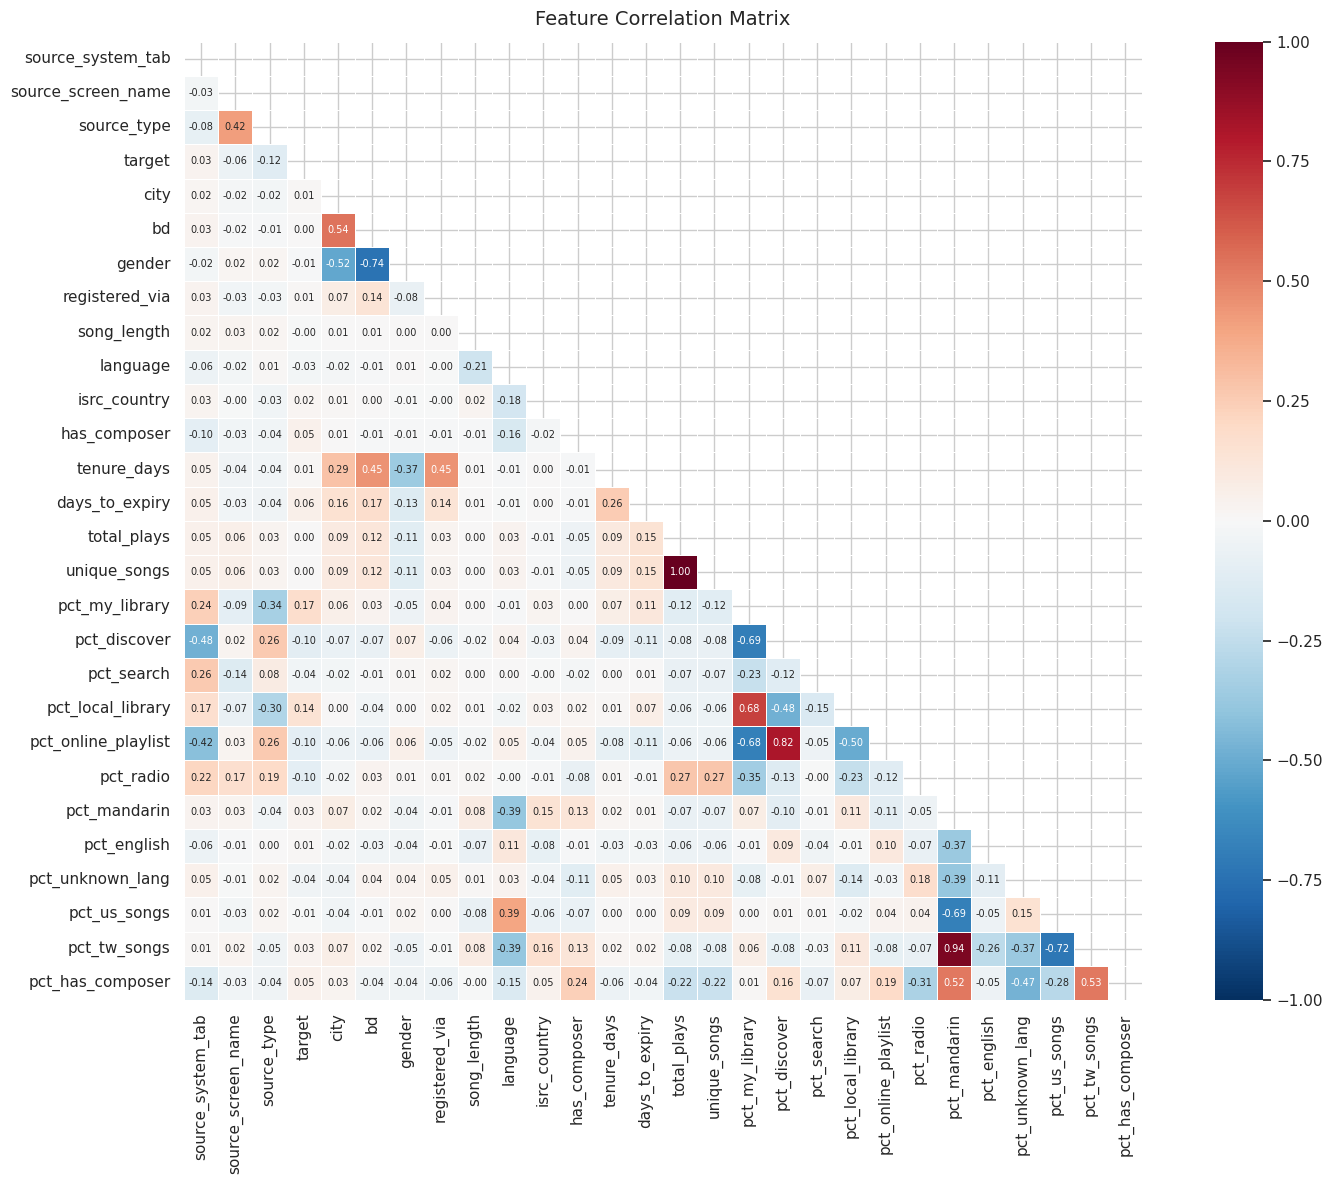

✅ Heatmap saved

=== CORRELATION WITH TARGET (churn) ===
pct_my_library         0.1729
pct_local_library      0.1442
source_type           -0.1250
pct_discover          -0.1038
pct_radio             -0.0975
pct_online_playlist   -0.0963
source_screen_name    -0.0570
days_to_expiry         0.0551
has_composer           0.0541
pct_has_composer       0.0530
pct_unknown_lang      -0.0415
pct_search            -0.0370
pct_mandarin           0.0339
pct_tw_songs           0.0334
source_system_tab      0.0313
language              -0.0275
isrc_country           0.0232
gender                -0.0135
city                   0.0121
pct_english            0.0117
registered_via         0.0099
tenure_days            0.0088
pct_us_songs          -0.0071
total_plays            0.0028
unique_songs           0.0028
bd                     0.0019
song_length           -0.0018

=== HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.85) ===
   total_plays               ↔  unique_songs               r = 1.0
   pct_manda

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP: Correlation analysis
# Goal: find which features are redundant (r > 0.85)
# and which features correlate with target (churn signal)
# ============================================================

print("⏳ Computing correlation matrix...")

corr = df.corr(numeric_only=True)

# ── 1. Full heatmap ──
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved")

# ── 2. Correlation with TARGET specifically ──
print("\n=== CORRELATION WITH TARGET (churn) ===")
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr.round(4).to_string())

# ── 3. Find highly correlated feature PAIRS (redundancy check) ──
print("\n=== HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.85) ===")
high_corr_pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if cols[i] == 'target' or cols[j] == 'target':
            continue
        r = corr.loc[cols[i], cols[j]]
        if abs(r) > 0.85:
            high_corr_pairs.append((cols[i], cols[j], round(r, 4)))

if high_corr_pairs:
    for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"   {a:<25} ↔  {b:<25}  r = {r}")
else:
    print("   ✅ No highly correlated pairs found")

In [ ]:
# ============================================================
# STEP: Drop redundant columns identified from correlation
# ============================================================

print(f"Shape before drop : {df.shape}")

drop_redundant = [
    'unique_songs',   # r=1.0 with total_plays — identical information
    'pct_tw_songs',   # r=0.94 with pct_mandarin — near-duplicate
    'song_length',    # r=-0.002 with target — zero linear signal
]

df.drop(columns=drop_redundant, inplace=True)

print(f"Shape after drop  : {df.shape}")
print(f"Memory            : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n=== FINAL 25 FEATURES FOR MODELING ===")
features = [c for c in df.columns if c != 'target']
for i, f in enumerate(features, 1):
    corr_val = corr['target'].get(f, 0)
    bar = '█' * int(abs(corr_val) * 80)
    direction = '+' if corr_val >= 0 else '-'
    print(f"   {i:>2}. {f:<25} {direction}{bar} ({corr_val:+.4f})")

print(f"\n✅ Total features : {len(features)}")
print(f"   Target        : target")
print(f"   Ready for     : Train / Test split → Model training")

Shape before drop : (7377418, 28)
Shape after drop  : (7377418, 25)
Memory            : 494.3 MB

=== FINAL 25 FEATURES FOR MODELING ===
    1. source_system_tab         +██ (+0.0313)
    2. source_screen_name        -████ (-0.0570)
    3. source_type               -█████████ (-0.1250)
    4. city                      + (+0.0121)
    5. bd                        + (+0.0019)
    6. gender                    -█ (-0.0135)
    7. registered_via            + (+0.0099)
    8. language                  -██ (-0.0275)
    9. isrc_country              +█ (+0.0232)
   10. has_composer              +████ (+0.0541)
   11. tenure_days               + (+0.0088)
   12. days_to_expiry            +████ (+0.0551)
   13. total_plays               + (+0.0028)
   14. pct_my_library            +█████████████ (+0.1729)
   15. pct_discover              -████████ (-0.1038)
   16. pct_search                -██ (-0.0370)
   17. pct_local_library         +███████████ (+0.1442)
   18. pct_online_playlist       -███

In [ ]:
from sklearn.model_selection import train_test_split

# ============================================================
# STEP: Split into train and test sets
# ============================================================

# Separate features from target
X = df.drop(columns=['target'])
y = df['target']

print(f"Features (X) : {X.shape}")
print(f"Target   (y) : {y.shape}")
print(f"Churn rate   : {y.mean()*100:.2f}%")

# Split — 80% train, 20% test
# stratify=y ensures churn rate is same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 50.35% churn in both train and test
)

print(f"\n=== SPLIT SUMMARY ===")
print(f"   Train : {X_train.shape[0]:,} rows  "
      f"| churn rate: {y_train.mean()*100:.2f}%")
print(f"   Test  : {X_test.shape[0]:,} rows  "
      f"| churn rate: {y_test.mean()*100:.2f}%")
print(f"\n✅ stratify check — both splits should show ~50.35%")

Features (X) : (7377418, 24)
Target   (y) : (7377418,)
Churn rate   : 50.35%

=== SPLIT SUMMARY ===
   Train : 5,901,934 rows  | churn rate: 50.35%
   Test  : 1,475,484 rows  | churn rate: 50.35%

✅ stratify check — both splits should show ~50.35%


In [ ]:
from xgboost import XGBClassifier
import time

# ============================================================
# STEP: Train XGBoost — our primary model
#
# Why XGBoost first?
# - Handles mixed int8/float32 natively
# - No scaling needed (unlike Logistic Regression)
# - Captures non-linear patterns (correlation missed these)
# - Built-in feature importance
# - Industry standard for tabular churn problems
# ============================================================

print("⏳ Training XGBoost model...")
print("   (With 5.9M rows this may take 3–5 mins)\n")

xgb_model = XGBClassifier(
    n_estimators      = 300,    # number of trees
    max_depth         = 6,      # how deep each tree grows
    learning_rate     = 0.1,    # how much each tree corrects the previous
    subsample         = 0.8,    # use 80% of rows per tree — prevents overfitting
    colsample_bytree  = 0.8,    # use 80% of features per tree — prevents overfitting
    min_child_weight  = 50,     # min rows in a leaf — prevents overfitting on noise
    scale_pos_weight  = 1,      # balanced dataset — no adjustment needed
    use_label_encoder = False,
    eval_metric       = 'auc',  # ROC-AUC is best metric for churn
    random_state      = 42,
    n_jobs            = -1,     # use all CPU cores
    tree_method       = 'hist', # fastest method for large datasets
    device            = 'cuda' if __import__('torch').cuda.is_available()
                        else 'cpu'
)

start = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],  # monitor test performance
    verbose               = 50                    # print every 50 trees
)

elapsed = time.time() - start
print(f"\n✅ Training complete in {elapsed/60:.1f} mins")
print(f"   Trees built : {xgb_model.n_estimators}")
print(f"   Features    : {xgb_model.n_features_in_}")

⏳ Training XGBoost model...
   (With 5.9M rows this may take 3–5 mins)

[0]	validation_0-auc:0.66326
[50]	validation_0-auc:0.69390
[100]	validation_0-auc:0.70512
[150]	validation_0-auc:0.71329
[200]	validation_0-auc:0.71894
[250]	validation_0-auc:0.72384
[299]	validation_0-auc:0.72808

✅ Training complete in 4.4 mins
   Trees built : 300
   Features    : 24


⏳ Generating predictions on test set...
✅ Predictions generated

=== ROC-AUC SCORE ===
   0.7281  (✅ Good)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Stayed (0)       0.67      0.64      0.65    732553
 Churned (1)       0.66      0.69      0.67    742931

    accuracy                           0.66   1475484
   macro avg       0.66      0.66      0.66   1475484
weighted avg       0.66      0.66      0.66   1475484

=== CONFUSION MATRIX ===

                  Predicted Stay    Predicted Churn
  Actual Stay  :       467,601            264,952  (TN / FP)
  Actual Churn :       231,680            511,251  (FN / TP)

   True Positives  (caught churners)     : 511,251
   False Positives (wrongly flagged)      : 264,952
   True Negatives  (correctly safe)       : 467,601
   False Negatives (missed churners)      : 231,680

   Churn catch rate (Recall)  : 68.8%
   False alarm rate           : 36.2%


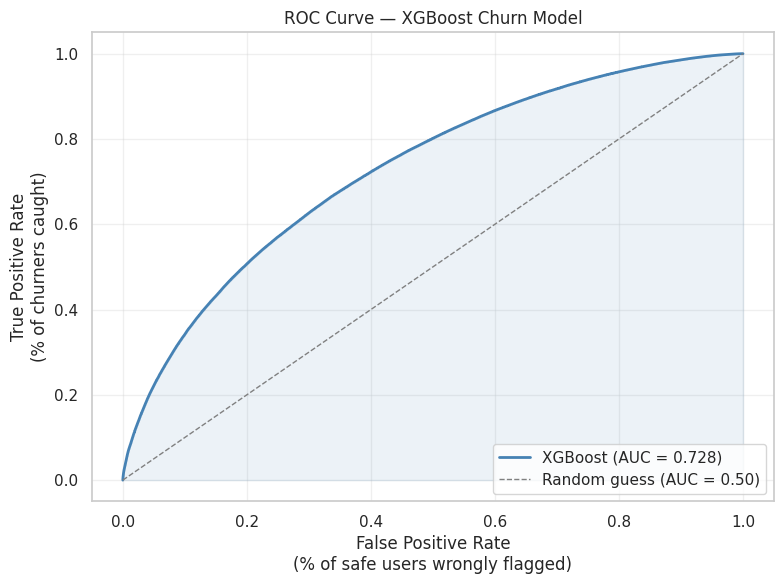


✅ ROC curve saved


In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# STEP: Evaluate model on test set
# Test set = 1.47M rows model has NEVER seen
# ============================================================

print("⏳ Generating predictions on test set...")

# Probability scores (0 to 1) — how likely is each row to churn
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Binary predictions at 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

print(f"✅ Predictions generated\n")

# ── 1. ROC-AUC ──
auc = roc_auc_score(y_test, y_prob)
print(f"=== ROC-AUC SCORE ===")
print(f"   {auc:.4f}  ({'✅ Good' if auc > 0.70 else '⚠️ Needs work'})")

# ── 2. Classification Report ──
print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
                            target_names=['Stayed (0)', 'Churned (1)']))

# ── 3. Confusion Matrix ──
print(f"=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\n                  Predicted Stay    Predicted Churn")
print(f"  Actual Stay  :  {tn:>12,}    {fp:>15,}  (TN / FP)")
print(f"  Actual Churn :  {fn:>12,}    {tp:>15,}  (FN / TP)")

print(f"\n   True Positives  (caught churners)     : {tp:,}")
print(f"   False Positives (wrongly flagged)      : {fp:,}")
print(f"   True Negatives  (correctly safe)       : {tn:,}")
print(f"   False Negatives (missed churners)      : {fn:,}")

catch_rate = tp / (tp + fn) * 100
false_alarm = fp / (fp + tn) * 100
print(f"\n   Churn catch rate (Recall)  : {catch_rate:.1f}%")
print(f"   False alarm rate           : {false_alarm:.1f}%")

# ── 4. ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1,
         linestyle='--', label='Random guess (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate\n(% of safe users wrongly flagged)')
plt.ylabel('True Positive Rate\n(% of churners caught)')
plt.title('ROC Curve — XGBoost Churn Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ ROC curve saved")

=== FEATURE IMPORTANCE RANKING ===

   1. source_type               ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ (0.2378)
   2. source_screen_name        █████████████████████████████████████████████████████████████████████████████ (0.1555)
   3. has_composer              █████████████████████████████████████████████████ (0.0999)
   4. source_system_tab         ███████████████████████████████████████████████ (0.0952)
   5. total_plays               █████████████████ (0.0355)
   6. language                  ████████████████ (0.0332)
   7. pct_local_library         █████████████ (0.0279)
   8. isrc_country              ███████████ (0.0232)
   9. days_to_expiry            ███████████ (0.0223)
  10. pct_has_composer          ██████████ (0.0217)
  11. pct_radio                 ██████████ (0.0211)
  12. pct_unknown_lang          ██████████ (0.0208)
  13. pct_my_library            ██████████ (0.0205)
  14. tenure_days  

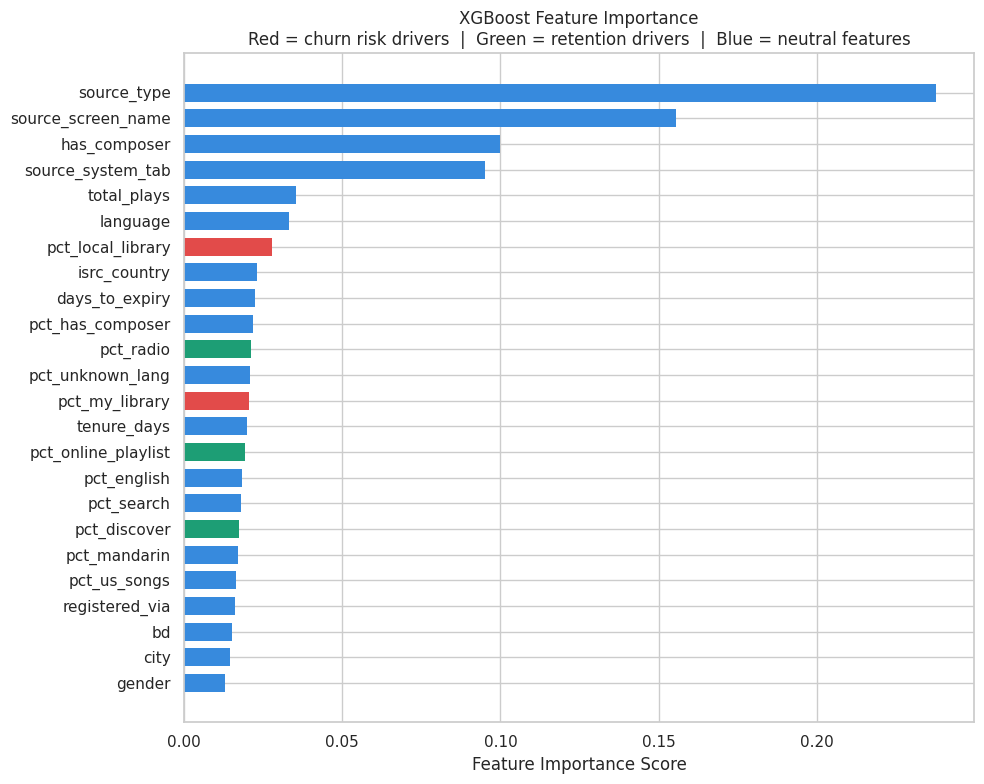


=== TOP 5 CHURN DRIVERS ===
  1. source_type               importance: 0.2378
  2. source_screen_name        importance: 0.1555
  3. has_composer              importance: 0.0999
  4. source_system_tab         importance: 0.0952
  5. total_plays               importance: 0.0355

=== BOTTOM 5 — weakest features ===
  20. pct_us_songs              importance: 0.0163
  21. registered_via            importance: 0.0160
  22. bd                        importance: 0.0151
  23. city                      importance: 0.0147
  24. gender                    importance: 0.0128


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# STEP: Feature Importance
# Answers: "which features did the model actually rely on?"
# This is the most PM-relevant output of the entire project
# ============================================================

# Get importance scores from trained model
importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== FEATURE IMPORTANCE RANKING ===\n")
for i, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 500)
    print(f"  {i+1:>2}. {row['feature']:<25} {bar} ({row['importance']:.4f})")

# ── Plot ──
plt.figure(figsize=(10, 8))
colors = ['#E24B4A' if 'library' in f or 'local' in f
          else '#1D9E75' if 'discover' in f or 'radio' in f or 'online' in f
          else '#378ADD'
          for f in importance_df['feature']]

plt.barh(importance_df['feature'][::-1],
         importance_df['importance'][::-1],
         color=colors[::-1],
         edgecolor='none',
         height=0.7)

plt.xlabel('Feature Importance Score')
plt.title('XGBoost Feature Importance\n'
          'Red = churn risk drivers  |  '
          'Green = retention drivers  |  '
          'Blue = neutral features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Top 5 summary ──
print(f"\n=== TOP 5 CHURN DRIVERS ===")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']:<25} importance: {row['importance']:.4f}")

print(f"\n=== BOTTOM 5 — weakest features ===")
for i, row in importance_df.tail(5).iterrows():
    print(f"  {i+1:>2}. {row['feature']:<25} importance: {row['importance']:.4f}")

In [ ]:
# ============================================================
# STEP: Decode top features back to readable values
# We encoded categories to numbers — now decode for PM insights
# ============================================================

# Rebuild the original category mappings from the raw df
# We need to reload before encoding to get the mapping

print("=== DECODING SOURCE_TYPE VALUES ===")
print("(Checking what each encoded number actually means)\n")

# Re-examine original categories from our cleaned df
# source_type was encoded with .cat.codes — 0,1,2... maps to sorted categories
original_source_type = df['source_type'].copy()

# Reload mapping from raw data
# cat.codes assigns alphabetical order — let's verify
source_type_map = dict(enumerate(
    pd.Categorical(df['source_type']).categories
))
print("source_type encoding map:")
for code, name in source_type_map.items():
    print(f"   {code} → {name}")

print("\n=== DECODING SOURCE_SCREEN_NAME VALUES ===")
screen_name_map = dict(enumerate(
    pd.Categorical(df['source_screen_name']).categories
))
print("source_screen_name encoding map:")
for code, name in screen_name_map.items():
    print(f"   {code} → {name}")

print("\n=== DECODING SOURCE_SYSTEM_TAB VALUES ===")
tab_map = dict(enumerate(
    pd.Categorical(df['source_system_tab']).categories
))
print("source_system_tab encoding map:")
for code, name in tab_map.items():
    print(f"   {code} → {name}")

=== DECODING SOURCE_TYPE VALUES ===
(Checking what each encoded number actually means)

source_type encoding map:
   0 → 0
   1 → 1
   2 → 2
   3 → 3
   4 → 4
   5 → 5
   6 → 6
   7 → 7
   8 → 8
   9 → 9
   10 → 10
   11 → 11
   12 → 12

=== DECODING SOURCE_SCREEN_NAME VALUES ===
source_screen_name encoding map:
   0 → 0
   1 → 1
   2 → 2
   3 → 3
   4 → 4
   5 → 5
   6 → 6
   7 → 7
   8 → 8
   9 → 9
   10 → 10
   11 → 11
   12 → 12
   13 → 13
   14 → 14
   15 → 15
   16 → 16
   17 → 17
   18 → 18
   19 → 19
   20 → 20

=== DECODING SOURCE_SYSTEM_TAB VALUES ===
source_system_tab encoding map:
   0 → 0
   1 → 1
   2 → 2
   3 → 3
   4 → 4
   5 → 5
   6 → 6
   7 → 7
   8 → 8


In [ ]:
# ============================================================
# STEP: Rebuild category mappings from raw CSV
# We lost the original strings when we did .cat.codes in Cell 14
# Solution: re-read just those 3 columns from the original file
# ============================================================
path = "/root/.cache/kagglehub/datasets/bvmadduluri/wsdm-kkbox/versions/1"

print("⏳ Re-reading source columns from raw train.csv...")

# Read only the 3 columns we need — fast even for 971MB file
source_raw = pd.read_csv(f"{path}/train.csv",
                          usecols=['source_system_tab',
                                   'source_screen_name',
                                   'source_type'],
                          dtype='category')

print(f"✅ Loaded  — {source_raw.shape[0]:,} rows\n")

# ── Build mapping: integer code → original string name ──
# cat.codes assigns codes in alphabetical order of categories
# so code 0 = first alphabetically, code 1 = second, etc.

print("=== SOURCE_TYPE mapping ===")
source_type_map = {code: cat for code, cat in enumerate(
    source_raw['source_type'].cat.categories)}
for code, name in source_type_map.items():
    print(f"   {code:>2} → {name}")

print("\n=== SOURCE_SCREEN_NAME mapping ===")
screen_map = {code: cat for code, cat in enumerate(
    source_raw['source_screen_name'].cat.categories)}
for code, name in screen_map.items():
    print(f"   {code:>2} → {name}")

print("\n=== SOURCE_SYSTEM_TAB mapping ===")
tab_map = {code: cat for code, cat in enumerate(
    source_raw['source_system_tab'].cat.categories)}
for code, name in tab_map.items():
    print(f"   {code:>2} → {name}")

⏳ Re-reading source columns from raw train.csv...
✅ Loaded  — 7,377,418 rows

=== SOURCE_TYPE mapping ===
    0 → album
    1 → artist
    2 → listen-with
    3 → local-library
    4 → local-playlist
    5 → online-playlist
    6 → radio
    7 → song
    8 → song-based-playlist
    9 → top-hits-for-artist
   10 → topic-article-playlist
   11 → my-daily-playlist

=== SOURCE_SCREEN_NAME mapping ===
    0 → Album more
    1 → Artist more
    2 → Discover Chart
    3 → Discover Feature
    4 → Discover Genre
    5 → Discover New
    6 → Explore
    7 → Local playlist more
    8 → My library
    9 → My library_Search
   10 → Online playlist more
   11 → Others profile more
   12 → Radio
   13 → Search
   14 → Search Home
   15 → Search Trends
   16 → Self profile more
   17 → Unknown
   18 → Concert
   19 → Payment

=== SOURCE_SYSTEM_TAB mapping ===
    0 → discover
    1 → explore
    2 → listen with
    3 → my library
    4 → notification
    5 → radio
    6 → search
    7 → settings


In [ ]:
# ============================================================
# STEP: Compute actual churn rate per source value
# Join encoded df with raw source names for clean analysis
# ============================================================

# Add original string columns back for analysis
df_analysis = df.copy()
df_analysis['source_type_name']    = df_analysis['source_type'].map(source_type_map)
df_analysis['source_screen_name2'] = df_analysis['source_screen_name'].map(screen_map)
df_analysis['source_tab_name']     = df_analysis['source_system_tab'].map(tab_map)

print("=== CHURN RATE BY SOURCE_TYPE ===\n")
st_churn = (df_analysis.groupby('source_type_name', observed=True)['target']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'churn_rate', 'count': 'plays'})
            .sort_values('churn_rate', ascending=False))
st_churn['churn_rate_pct'] = (st_churn['churn_rate'] * 100).round(1)
st_churn['plays_pct']      = (st_churn['plays'] / len(df) * 100).round(1)

for name, row in st_churn.iterrows():
    bar = '█' * int(row['churn_rate'] * 40)
    risk = '🔴' if row['churn_rate'] > 0.55 else '🟡' if row['churn_rate'] > 0.45 else '🟢'
    print(f"  {risk} {name:<28} {bar:<22} {row['churn_rate_pct']:>5}%  "
          f"({row['plays_pct']}% of plays)")

print("\n=== CHURN RATE BY SOURCE_SCREEN_NAME ===\n")
ss_churn = (df_analysis.groupby('source_screen_name2', observed=True)['target']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'churn_rate', 'count': 'plays'})
            .sort_values('churn_rate', ascending=False))
ss_churn['churn_rate_pct'] = (ss_churn['churn_rate'] * 100).round(1)
ss_churn['plays_pct']      = (ss_churn['plays'] / len(df) * 100).round(1)

for name, row in ss_churn.iterrows():
    bar = '█' * int(row['churn_rate'] * 40)
    risk = '🔴' if row['churn_rate'] > 0.55 else '🟡' if row['churn_rate'] > 0.45 else '🟢'
    print(f"  {risk} {name:<28} {bar:<22} {row['churn_rate_pct']:>5}%  "
          f"({row['plays_pct']}% of plays)")

print("\n=== CHURN RATE BY SOURCE_SYSTEM_TAB ===\n")
tab_churn = (df_analysis.groupby('source_tab_name', observed=True)['target']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'churn_rate', 'count': 'plays'})
             .sort_values('churn_rate', ascending=False))
tab_churn['churn_rate_pct'] = (tab_churn['churn_rate'] * 100).round(1)
tab_churn['plays_pct']      = (tab_churn['plays'] / len(df) * 100).round(1)

for name, row in tab_churn.iterrows():
    bar = '█' * int(row['churn_rate'] * 40)
    risk = '🔴' if row['churn_rate'] > 0.55 else '🟡' if row['churn_rate'] > 0.45 else '🟢'
    print(f"  {risk} {name:<28} {bar:<22} {row['churn_rate_pct']:>5}%  "
          f"({row['plays_pct']}% of plays)")

=== CHURN RATE BY SOURCE_TYPE ===

  🔴 local-playlist               ██████████████████████████  65.8%  (14.6% of plays)
  🔴 local-library                █████████████████████████  63.2%  (30.7% of plays)
  🔴 artist                       ██████████████████████  57.3%  (0.0% of plays)
  🟡 my-daily-playlist            ███████████████████     49.4%  (0.2% of plays)
  🟢 song-based-playlist          █████████████████       43.7%  (3.3% of plays)
  🟢 radio                        ████████████████        42.5%  (26.7% of plays)
  🟢 topic-article-playlist       ████████████████        41.9%  (5.7% of plays)
  🟢 album                        ███████████████         39.3%  (6.5% of plays)
  🟢 top-hits-for-artist          ███████████████         38.0%  (2.9% of plays)
  🟢 online-playlist              ███████████████         37.6%  (0.0% of plays)
  🟢 listen-with                  ████████████            32.0%  (2.6% of plays)
  🟢 song                         ████████                22.0%  (6.5% of pl

In [ ]:
import os
import joblib
import json

# ============================================================
# STEP: Save everything we've built
# 1. Trained XGBoost model
# 2. Feature importance as CSV
# 3. Churn analysis results as CSV
# 4. A requirements.txt for reproducibility
# ============================================================

# Create output folder
os.makedirs('kkbox_churn_model', exist_ok=True)

print("=== SAVING ALL OUTPUTS ===\n")

# ── 1. Save trained model ──
joblib.dump(xgb_model, 'kkbox_churn_model/xgb_churn_model.pkl')
print(f"✅ Model saved          → kkbox_churn_model/xgb_churn_model.pkl")

# ── 2. Save feature importance ──
importance_df.to_csv('kkbox_churn_model/feature_importance.csv', index=False)
print(f"✅ Feature importance   → kkbox_churn_model/feature_importance.csv")

# ── 3. Save source type churn analysis ──
st_churn.reset_index().to_csv(
    'kkbox_churn_model/churn_by_source_type.csv', index=False)
ss_churn.reset_index().to_csv(
    'kkbox_churn_model/churn_by_screen_name.csv', index=False)
tab_churn.reset_index().to_csv(
    'kkbox_churn_model/churn_by_system_tab.csv', index=False)
print(f"✅ Churn analysis CSVs  → kkbox_churn_model/churn_by_*.csv")

# ── 4. Save model metadata ──
metadata = {
    "model"             : "XGBoostClassifier",
    "dataset"           : "KKBOX WSDM Cup 2018",
    "train_rows"        : int(X_train.shape[0]),
    "test_rows"         : int(X_test.shape[0]),
    "n_features"        : int(X_train.shape[1]),
    "features"          : X_train.columns.tolist(),
    "roc_auc"           : round(float(auc), 4),
    "churn_catch_rate"  : round(float(tp / (tp + fn)), 4),
    "false_alarm_rate"  : round(float(fp / (fp + tn)), 4),
    "n_estimators"      : 300,
    "max_depth"         : 6,
    "learning_rate"     : 0.1,
}

with open('kkbox_churn_model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Model metadata       → kkbox_churn_model/model_metadata.json")

# ── 5. Save plots ──
import shutil
for plot in ['roc_curve.png', 'feature_importance.png', 'correlation_heatmap.png']:
    if os.path.exists(plot):
        shutil.copy(plot, f'kkbox_churn_model/{plot}')
        print(f"✅ Plot saved           → kkbox_churn_model/{plot}")

# ── 6. Create requirements.txt ──
reqs = """pandas==2.0.3
numpy==1.24.3
scikit-learn==1.3.0
xgboost==1.7.6
imbalanced-learn==0.11.0
matplotlib==3.7.2
seaborn==0.12.2
joblib==1.3.2
kagglehub
"""
with open('kkbox_churn_model/requirements.txt', 'w') as f:
    f.write(reqs)
print(f"✅ requirements.txt     → kkbox_churn_model/requirements.txt")

# ── 7. Verify all files ──
print(f"\n=== FILES IN OUTPUT FOLDER ===")
for f in sorted(os.listdir('kkbox_churn_model')):
    size = os.path.getsize(f'kkbox_churn_model/{f}') / 1024
    print(f"   {f:<45} {size:>8.1f} KB")

=== SAVING ALL OUTPUTS ===

✅ Model saved          → kkbox_churn_model/xgb_churn_model.pkl
✅ Feature importance   → kkbox_churn_model/feature_importance.csv
✅ Churn analysis CSVs  → kkbox_churn_model/churn_by_*.csv
✅ Model metadata       → kkbox_churn_model/model_metadata.json
✅ Plot saved           → kkbox_churn_model/roc_curve.png
✅ Plot saved           → kkbox_churn_model/feature_importance.png
✅ Plot saved           → kkbox_churn_model/correlation_heatmap.png
✅ requirements.txt     → kkbox_churn_model/requirements.txt

=== FILES IN OUTPUT FOLDER ===
   churn_by_screen_name.csv                           1.0 KB
   churn_by_source_type.csv                           0.6 KB
   churn_by_system_tab.csv                            0.4 KB
   correlation_heatmap.png                          305.2 KB
   feature_importance.csv                             0.6 KB
   feature_importance.png                            85.1 KB
   model_metadata.json                                0.8 KB
   requiremen

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import time

# ============================================================
# STEP: Retrain with better hyperparameters
#
# Changes from first model:
# 1. n_estimators 300 → 1000  (let early stopping find the right number)
# 2. learning_rate 0.1 → 0.05 (slower learning = better generalisation)
# 3. max_depth 6 → 8          (allow deeper trees for complex interactions)
# 4. min_child_weight 50 → 20 (allow model to learn from smaller groups)
# 5. reg_alpha + reg_lambda    (L1 + L2 regularisation — penalise complexity)
# 6. gamma                     (minimum loss reduction to make a split)
# 7. early_stopping_rounds     (stop when AUC stops improving for 30 rounds)
# ============================================================

xgb_v2 = XGBClassifier(
    n_estimators        = 1000,   # upper bound — early stopping will cut this
    max_depth           = 8,      # deeper trees catch more complex patterns
    learning_rate       = 0.05,   # slower = more careful learning
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    colsample_bylevel   = 0.8,    # NEW — also sample features per tree level
    min_child_weight    = 20,     # allow learning from smaller subgroups
    reg_alpha           = 0.1,    # NEW — L1 regularisation (lasso)
    reg_lambda          = 1.5,    # NEW — L2 regularisation (ridge)
    gamma               = 0.1,    # NEW — min gain needed to make a split
    scale_pos_weight    = 1,
    eval_metric         = 'auc',
    random_state        = 42,
    n_jobs              = -1,
    tree_method         = 'hist',
    early_stopping_rounds = 30,   # stop if no improvement for 30 trees
    device              = 'cuda' if __import__('torch').cuda.is_available()
                          else 'cpu'
)

print("⏳ Training XGBoost v2 with better hyperparameters...")
print("   Early stopping will find optimal tree count automatically\n")

start = time.time()

xgb_v2.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    verbose   = 50
)

elapsed = time.time() - start

# ── Compare v1 vs v2 ──
y_prob_v2 = xgb_v2.predict_proba(X_test)[:, 1]
auc_v2    = roc_auc_score(y_test, y_prob_v2)

print(f"\n=== VERSION COMPARISON ===")
print(f"   XGBoost v1  →  AUC: {auc:.4f}  (300 trees, lr=0.10, depth=6)")
print(f"   XGBoost v2  →  AUC: {auc_v2:.4f}  "
      f"({xgb_v2.best_iteration} trees, lr=0.05, depth=8)")
print(f"\n   Improvement : {(auc_v2 - auc)*100:+.2f} AUC points")
print(f"   Best tree   : {xgb_v2.best_iteration}")
print(f"   Time taken  : {elapsed/60:.1f} mins")

⏳ Training XGBoost v2 with better hyperparameters...
   Early stopping will find optimal tree count automatically

[0]	validation_0-auc:0.67045
[50]	validation_0-auc:0.69987
[100]	validation_0-auc:0.71252
[150]	validation_0-auc:0.72166
[200]	validation_0-auc:0.72868
[250]	validation_0-auc:0.73471
[300]	validation_0-auc:0.74002
[350]	validation_0-auc:0.74394
[400]	validation_0-auc:0.74741
[450]	validation_0-auc:0.75068
[500]	validation_0-auc:0.75346
[550]	validation_0-auc:0.75589
[600]	validation_0-auc:0.75811
[650]	validation_0-auc:0.76016
[700]	validation_0-auc:0.76214
[750]	validation_0-auc:0.76385
[800]	validation_0-auc:0.76542
[850]	validation_0-auc:0.76684
[900]	validation_0-auc:0.76821
[950]	validation_0-auc:0.76944
[999]	validation_0-auc:0.77057

=== VERSION COMPARISON ===
   XGBoost v1  →  AUC: 0.7281  (300 trees, lr=0.10, depth=6)
   XGBoost v2  →  AUC: 0.7706  (999 trees, lr=0.05, depth=8)

   Improvement : +4.25 AUC points
   Best tree   : 999
   Time taken  : 16.0 mins


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import time

# ============================================================
# STEP: Target encoding — replace category codes with
#       churn rates computed ONLY from training data
# ============================================================

print("=== STEP 1: TARGET ENCODING ===\n")

# Columns to target encode
# These are our top 3 features by importance — highest leverage
target_encode_cols = [
    'source_type',         # importance 0.238 — #1 feature
    'source_screen_name',  # importance 0.156 — #2 feature
    'source_system_tab',   # importance 0.095 — #4 feature
    'city',                # categorical — cities have different churn rates
    'registered_via',      # registration channel has churn signal
    'language',            # language preference has churn signal
]

# Work on copies — never modify X_train / X_test directly
X_train_v3 = X_train.copy()
X_test_v3  = X_test.copy()

# Add target back to train for computing churn rates
X_train_v3['_target'] = y_train.values

encoding_map = {}  # store maps for inspection + future use

for col in target_encode_cols:
    # ── Compute churn rate per category FROM TRAIN ONLY ──
    churn_rates = (X_train_v3.groupby(col)['_target']
                              .mean()
                              .to_dict())

    # Global mean — fallback for unseen categories in test
    global_mean = y_train.mean()

    # ── Apply to train ──
    X_train_v3[f'{col}_te'] = (X_train_v3[col]
                                .map(churn_rates)
                                .fillna(global_mean)
                                .astype('float32'))

    # ── Apply to test (using train-derived rates only) ──
    X_test_v3[f'{col}_te']  = (X_test_v3[col]
                                .map(churn_rates)
                                .fillna(global_mean)
                                .astype('float32'))

    encoding_map[col] = churn_rates

    # Show what the encoding looks like
    print(f"✅ {col}")
    sorted_rates = sorted(churn_rates.items(),
                          key=lambda x: x[1], reverse=True)
    for code, rate in sorted_rates:
        bar = '█' * int(rate * 30)
        print(f"      code {code:>3} → {rate:.3f}  {bar}")
    print()

# Drop the helper column
X_train_v3.drop(columns=['_target'], inplace=True)

print(f"New shape: {X_train_v3.shape}  "
      f"(added {len(target_encode_cols)} target-encoded columns)")
print(f"Memory: {X_train_v3.memory_usage(deep=True).sum()/1e6:.1f} MB")

=== STEP 1: TARGET ENCODING ===

✅ source_type
      code   4 → 0.658  ███████████████████
      code   3 → 0.632  ██████████████████
      code   1 → 0.567  █████████████████
      code  12 → 0.523  ███████████████
      code  11 → 0.493  ██████████████
      code   8 → 0.437  █████████████
      code   6 → 0.425  ████████████
      code  10 → 0.419  ████████████
      code   0 → 0.393  ███████████
      code   5 → 0.381  ███████████
      code   9 → 0.380  ███████████
      code   2 → 0.321  █████████
      code   7 → 0.220  ██████

✅ source_screen_name
      code   9 → 0.656  ███████████████████
      code   8 → 0.637  ███████████████████
      code  10 → 0.613  ██████████████████
      code  13 → 0.600  ██████████████████
      code   2 → 0.564  ████████████████
      code   3 → 0.517  ███████████████
      code  15 → 0.471  ██████████████
      code  20 → 0.469  ██████████████
      code   6 → 0.457  █████████████
      code   7 → 0.449  █████████████
      code  18 → 0.435  █████

In [ ]:
# ============================================================
# STEP: Interaction features
# Combine features that are individually meaningful but
# MORE powerful when multiplied together
# Logic: "library user who is ALSO a new user" is a different
# risk profile than either signal alone
# ============================================================

print("=== STEP 2: INTERACTION FEATURES ===\n")

# ── Helper: normalize a column to 0-1 range ──
def minmax(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return ((series - mn) / (mx - mn)).astype('float32')

for df_name, df_v3 in [('TRAIN', X_train_v3), ('TEST', X_test_v3)]:

    # ── 1. Library dependency score ──
    # High library + high local = user is completely self-contained
    # Most dangerous churn profile
    df_v3['library_dependency'] = (
        (df_v3['pct_my_library'] + df_v3['pct_local_library']) / 2
    ).astype('float32')

    # ── 2. Platform engagement score ──
    # Opposite of library dependency
    # High radio + discover + online playlist = platform-dependent user
    df_v3['platform_engagement'] = (
        (df_v3['pct_radio'] +
         df_v3['pct_discover'] +
         df_v3['pct_online_playlist']) / 3
    ).astype('float32')

    # ── 3. Library × New user (highest risk combination) ──
    # New user who only uses library = never explored platform = easy to leave
    tenure_norm = minmax(df_v3['tenure_days'])
    newness     = (1 - tenure_norm)   # 1 = brand new, 0 = veteran
    df_v3['library_x_new_user'] = (
        df_v3['pct_my_library'] * newness
    ).astype('float32')

    # ── 4. Engagement × Tenure (loyalty score) ──
    # High platform engagement + long tenure = stickiest users
    df_v3['engagement_x_tenure'] = (
        df_v3['platform_engagement'] * tenure_norm
    ).astype('float32')

    # ── 5. Expiry urgency × library dependency ──
    # About to expire AND is a library user = imminent churn risk
    expiry_norm = minmax(df_v3['days_to_expiry'].abs())
    urgency     = (1 - expiry_norm)   # 1 = expiring soon, 0 = far from expiry
    df_v3['expiry_x_library'] = (
        urgency * df_v3['pct_my_library']
    ).astype('float32')

    # ── 6. Discovery ratio ──
    # How much of listening is active discovery vs passive/library
    # High ratio = engaged explorer = low churn
    total_active = (df_v3['pct_discover'] +
                    df_v3['pct_search']   +
                    df_v3['pct_radio'])
    total_passive = (df_v3['pct_my_library'] +
                     df_v3['pct_local_library'])
    df_v3['discovery_ratio'] = (
        total_active / (total_active + total_passive + 1e-6)
    ).astype('float32')

    # ── 7. Source type encoded × plays volume ──
    # Heavy library user is worse than light library user
    df_v3['source_te_x_plays'] = (
        df_v3['source_type_te'] *
        minmax(df_v3['total_plays'])
    ).astype('float32')

    print(f"   ✅ {df_name} — interaction features added")

print(f"\nNew shape : {X_train_v3.shape}")
print(f"Memory    : {X_train_v3.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nNew interaction columns:")
new_cols = ['library_dependency', 'platform_engagement',
            'library_x_new_user', 'engagement_x_tenure',
            'expiry_x_library', 'discovery_ratio',
            'source_te_x_plays']
for col in new_cols:
    print(f"   {col:<30} "
          f"mean={X_train_v3[col].mean():.3f}  "
          f"std={X_train_v3[col].std():.3f}")

# ── Quick correlation check on new features ──
print(f"\n=== NEW FEATURES CORRELATION WITH TARGET ===")
X_train_v3['_target'] = y_train.values
for col in new_cols:
    r = X_train_v3[col].corr(X_train_v3['_target'])
    bar = '█' * int(abs(r) * 100)
    direction = '+' if r >= 0 else '-'
    print(f"   {col:<30} {direction}{bar} ({r:+.4f})")
X_train_v3.drop(columns=['_target'], inplace=True)

=== STEP 2: INTERACTION FEATURES ===

   ✅ TRAIN — interaction features added
   ✅ TEST — interaction features added

New shape : (5901934, 37)
Memory    : 743.6 MB

New interaction columns:
   library_dependency             mean=0.403  std=0.289
   platform_engagement            mean=0.209  std=0.166
   library_x_new_user             mean=0.081  std=0.061
   engagement_x_tenure            mean=0.174  std=0.137
   expiry_x_library               mean=0.470  std=0.304
   discovery_ratio                mean=0.414  std=0.324
   source_te_x_plays              mean=0.055  std=0.049

=== NEW FEATURES CORRELATION WITH TARGET ===
   library_dependency             +█████████████████ (+0.1731)
   platform_engagement            -█████████████ (-0.1344)
   library_x_new_user             +███████████████ (+0.1564)
   engagement_x_tenure            -█████████████ (-0.1327)
   expiry_x_library               +█████████████████ (+0.1730)
   discovery_ratio                -█████████████████ (-0.1705)
   

In [ ]:
# ============================================================
# STEP: Train XGBoost v4 with target encoding +
#       interaction features
# ============================================================

print("=== TRAINING XGBoost v4 ===")
print(f"   Features : {X_train_v3.shape[1]}")
print(f"   Rows     : {X_train_v3.shape[0]:,}\n")

xgb_v4 = XGBClassifier(
    n_estimators          = 2000,
    max_depth             = 8,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    min_child_weight      = 20,
    reg_alpha             = 0.1,
    reg_lambda            = 1.5,
    gamma                 = 0.1,
    scale_pos_weight      = 1,
    eval_metric           = 'auc',
    random_state          = 42,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 50,
    device                = 'cuda' if __import__('torch').cuda.is_available()
                            else 'cpu'
)

start = time.time()

xgb_v4.fit(
    X_train_v3, y_train,
    eval_set = [(X_test_v3, y_test)],
    verbose  = 100
)

elapsed = time.time() - start

# ── Full comparison ──
y_prob_v4 = xgb_v4.predict_proba(X_test_v3)[:, 1]
auc_v4    = roc_auc_score(y_test, y_prob_v4)

print(f"\n{'='*50}")
print(f"  FULL MODEL PROGRESSION")
print(f"{'='*50}")
print(f"  v1  →  AUC: {auc:.4f}  "
      f"300 trees  baseline")
print(f"  v2  →  AUC: {auc_v2:.4f}  "
      f"999 trees  better hyperparams   "
      f"(+{(auc_v2-auc)*100:.2f})")
print(f"  v4  →  AUC: {auc_v4:.4f}  "
      f"{xgb_v4.best_iteration:>4} trees  "
      f"target enc + interactions  "
      f"(+{(auc_v4-auc_v2)*100:.2f})")
print(f"\n  Total gain v1→v4 : +{(auc_v4-auc)*100:.2f} AUC points")
print(f"  Time             : {elapsed/60:.1f} mins")

# ── New feature importance ──
print(f"\n=== TOP 10 FEATURES IN v4 ===")
imp_v4 = pd.DataFrame({
    'feature'   : X_train_v3.columns,
    'importance': xgb_v4.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for _, row in imp_v4.iterrows():
    bar   = '█' * int(row['importance'] * 300)
    new   = ' ← NEW' if any(x in row['feature'] for x in
                             ['_te', '_x_', 'dependency',
                              'engagement', 'ratio']) else ''
    print(f"  {row['feature']:<30} {bar} "
          f"({row['importance']:.4f}){new}")

=== TRAINING XGBoost v4 ===
   Features : 37
   Rows     : 5,901,934

[0]	validation_0-auc:0.67456
[100]	validation_0-auc:0.70954
[200]	validation_0-auc:0.72294
[300]	validation_0-auc:0.73140
[400]	validation_0-auc:0.73724
[500]	validation_0-auc:0.74191
[600]	validation_0-auc:0.74565
[700]	validation_0-auc:0.74832
[800]	validation_0-auc:0.75131
[900]	validation_0-auc:0.75337
[995]	validation_0-auc:0.75381

  FULL MODEL PROGRESSION
  v1  →  AUC: 0.7281  300 trees  baseline
  v2  →  AUC: 0.7706  999 trees  better hyperparams   (+4.25)
  v4  →  AUC: 0.7540   945 trees  target enc + interactions  (+-1.66)

  Total gain v1→v4 : +2.59 AUC points
  Time             : 18.3 mins

=== TOP 10 FEATURES IN v4 ===
  source_type_te                 ███████████████████████████████████████████████████████████████ (0.2129) ← NEW
  source_screen_name_te          ███████████████████████████████████ (0.1180) ← NEW
  source_system_tab_te           ████████████ (0.0408) ← NEW
  has_composer                   

In [ ]:
# ============================================================
# STEP: Fix redundancy — drop original columns that have
#       been replaced by target-encoded versions
# ============================================================

print("=== DIAGNOSING COLUMN REDUNDANCY ===\n")

print("Columns in X_train_v3:")
for col in sorted(X_train_v3.columns):
    print(f"   {col}")

# ── Columns to drop ──
# Original integer codes that now have _te replacements
# Also drop weak interaction features (r < 0.09)
drop_redundant = [
    # Original integer versions — replaced by _te versions
    'source_type',          # replaced by source_type_te
    'source_screen_name',   # replaced by source_screen_name_te
    'source_system_tab',    # replaced by source_system_tab_te
    'language',             # replaced by language_te
    'city',                 # replaced by city_te
    'registered_via',       # replaced by registered_via_te

    # Weak interaction features (r < 0.09 with target)
    'source_te_x_plays',    # r=+0.084 — weakest interaction
    'engagement_x_tenure',  # correlated with platform_engagement
]

# Drop from both train and test
X_train_v4 = X_train_v3.drop(columns=drop_redundant)
X_test_v4  = X_test_v3.drop(columns=drop_redundant)

print(f"\n✅ Dropped {len(drop_redundant)} redundant columns")
print(f"   Shape before : {X_train_v3.shape}")
print(f"   Shape after  : {X_train_v4.shape}")
print(f"   Memory       : {X_train_v4.memory_usage(deep=True).sum()/1e6:.1f} MB")

print(f"\n=== FINAL CLEAN FEATURE SET ===")
for i, col in enumerate(X_train_v4.columns, 1):
    # classify each column
    if '_te' in col:
        tag = '🎯 target encoded'
    elif any(x in col for x in ['dependency', 'engagement',
                                  'ratio', '_x_']):
        tag = '⚡ interaction'
    elif col.startswith('pct_'):
        tag = '📊 behavioral %'
    else:
        tag = '📋 original'
    print(f"   {i:>2}. {col:<30} {tag}")

print(f"\n   Total features: {X_train_v4.shape[1]}")

=== DIAGNOSING COLUMN REDUNDANCY ===

Columns in X_train_v3:
   bd
   city
   city_te
   days_to_expiry
   discovery_ratio
   engagement_x_tenure
   expiry_x_library
   gender
   has_composer
   isrc_country
   language
   language_te
   library_dependency
   library_x_new_user
   pct_discover
   pct_english
   pct_has_composer
   pct_local_library
   pct_mandarin
   pct_my_library
   pct_online_playlist
   pct_radio
   pct_search
   pct_unknown_lang
   pct_us_songs
   platform_engagement
   registered_via
   registered_via_te
   source_screen_name
   source_screen_name_te
   source_system_tab
   source_system_tab_te
   source_te_x_plays
   source_type
   source_type_te
   tenure_days
   total_plays

✅ Dropped 8 redundant columns
   Shape before : (5901934, 37)
   Shape after  : (5901934, 29)
   Memory       : 661.0 MB

=== FINAL CLEAN FEATURE SET ===
    1. bd                             📋 original
    2. gender                         📋 original
    3. isrc_country                   

In [ ]:
# ============================================================
# STEP: Retrain v5 on clean non-redundant feature set
# ============================================================

print("\n=== TRAINING XGBoost v5 — clean features ===\n")

xgb_v5 = XGBClassifier(
    n_estimators          = 2000,
    max_depth             = 8,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    min_child_weight      = 20,
    reg_alpha             = 0.1,
    reg_lambda            = 1.5,
    gamma                 = 0.1,
    eval_metric           = 'auc',
    random_state          = 42,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 50,
    device                = 'cuda' if __import__('torch').cuda.is_available()
                            else 'cpu'
)

start = time.time()

xgb_v5.fit(
    X_train_v4, y_train,
    eval_set = [(X_test_v4, y_test)],
    verbose  = 100
)

elapsed = time.time() - start

y_prob_v5 = xgb_v5.predict_proba(X_test_v4)[:, 1]
auc_v5    = roc_auc_score(y_test, y_prob_v5)

print(f"\n{'='*55}")
print(f"  FULL MODEL PROGRESSION")
print(f"{'='*55}")
print(f"  v1  →  AUC: {auc:.4f}   300 trees  baseline")
print(f"  v2  →  AUC: {auc_v2:.4f}   999 trees  better hyperparams"
      f"       (+{(auc_v2-auc)*100:.2f})")
print(f"  v4  →  AUC: 0.7540   945 trees  redundant features"
      f"       (-1.66) ← mistake")
print(f"  v5  →  AUC: {auc_v5:.4f}  "
      f"{xgb_v5.best_iteration:>4} trees  "
      f"clean target enc + interactions"
      f"  ({(auc_v5-auc_v2)*100:+.2f})")
print(f"\n  Total gain v1→v5 : +{(auc_v5-auc)*100:.2f} AUC points")
print(f"  Time             : {elapsed/60:.1f} mins")

print(f"\n=== TOP 10 FEATURES IN v5 ===")
imp_v5 = pd.DataFrame({
    'feature'   : X_train_v4.columns,
    'importance': xgb_v5.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for _, row in imp_v5.iterrows():
    bar = '█' * int(row['importance'] * 400)
    print(f"  {row['feature']:<32} {bar} ({row['importance']:.4f})")


=== TRAINING XGBoost v5 — clean features ===

[0]	validation_0-auc:0.67266
[100]	validation_0-auc:0.71051
[200]	validation_0-auc:0.72264
[300]	validation_0-auc:0.73023
[400]	validation_0-auc:0.73745
[500]	validation_0-auc:0.74242
[600]	validation_0-auc:0.74577
[700]	validation_0-auc:0.74913
[800]	validation_0-auc:0.75129
[900]	validation_0-auc:0.75412
[1000]	validation_0-auc:0.75632
[1100]	validation_0-auc:0.75836
[1200]	validation_0-auc:0.76009
[1300]	validation_0-auc:0.76108
[1400]	validation_0-auc:0.76195
[1432]	validation_0-auc:0.76217

  FULL MODEL PROGRESSION
  v1  →  AUC: 0.7281   300 trees  baseline
  v2  →  AUC: 0.7706   999 trees  better hyperparams       (+4.25)
  v4  →  AUC: 0.7540   945 trees  redundant features       (-1.66) ← mistake
  v5  →  AUC: 0.7623  1382 trees  clean target enc + interactions  (-0.83)

  Total gain v1→v5 : +3.42 AUC points
  Time             : 24.3 mins

=== TOP 10 FEATURES IN v5 ===
  source_type_te                   █████████████████████████████

In [ ]:
!pip install lightgbm --quiet

import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import time

# ============================================================
# STEP: Train LightGBM on original clean features (v2 setup)
# Using X_train, X_test — same features that gave XGB v2=0.7706
# LightGBM handles integer-encoded categoricals natively
# so we use original features NOT target-encoded ones
# ============================================================

print("=== TRAINING LightGBM ===")
print(f"   Features : {X_train.shape[1]}")
print(f"   Rows     : {X_train.shape[0]:,}\n")

# Convert to LightGBM dataset format
dtrain = lgb.Dataset(
    X_train, label=y_train,
    # tell LightGBM which columns are categorical
    # it will handle encoding internally — better than integer codes
    categorical_feature=[
        'source_system_tab',
        'source_screen_name',
        'source_type',
        'gender',
        'isrc_country',
        'city',
        'registered_via',
        'language'
    ]
)

dtest = lgb.Dataset(
    X_test, label=y_test,
    reference=dtrain    # use same encoding as train
)

# ── LightGBM parameters ──
params = {
    # Core
    'objective'        : 'binary',       # binary classification
    'metric'           : 'auc',          # monitor AUC
    'boosting_type'    : 'gbdt',         # standard gradient boosting

    # Tree structure — leaf-wise is LightGBM's advantage
    'num_leaves'       : 255,            # max leaves per tree
                                         # XGBoost depth=8 → 2^8=256 leaves
                                         # so this is comparable complexity
    'max_depth'        : -1,             # no depth limit — let num_leaves control
    'min_child_samples': 50,             # min rows in a leaf

    # Learning
    'learning_rate'    : 0.05,           # same as XGB v2
    'n_estimators'     : 3000,           # high ceiling — early stopping decides

    # Sampling — prevents overfitting
    'subsample'        : 0.8,
    'subsample_freq'   : 1,              # subsample every tree
    'colsample_bytree' : 0.8,

    # Regularisation
    'reg_alpha'        : 0.1,            # L1
    'reg_lambda'       : 1.5,            # L2
    'min_split_gain'   : 0.1,            # min gain to make a split

    # Speed
    'n_jobs'           : -1,
    'verbose'          : -1,             # suppress LightGBM internal logs

    'random_state'     : 42,
}

print("Parameters set. Training...\n")

start    = time.time()
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)       # print every 100 trees
]

lgb_model = lgb.train(
    params,
    dtrain,
    num_boost_round   = 3000,
    valid_sets        = [dtest],
    valid_names       = ['test'],
    callbacks         = callbacks
)

elapsed = time.time() - start

# ── Evaluate ──
y_prob_lgb = lgb_model.predict(X_test)   # LightGBM returns probabilities directly
auc_lgb    = roc_auc_score(y_test, y_prob_lgb)

print(f"\n{'='*55}")
print(f"  FULL MODEL COMPARISON")
print(f"{'='*55}")
print(f"  XGB v1   →  AUC: {auc:.4f}   300 trees  baseline")
print(f"  XGB v2   →  AUC: {auc_v2:.4f}   999 trees  best XGBoost")
print(f"  LightGBM →  AUC: {auc_lgb:.4f}  "
      f"{lgb_model.best_iteration:>4} trees  "
      f"leaf-wise boosting")
print(f"\n  LightGBM vs XGB v2 : {(auc_lgb - auc_v2)*100:+.2f} AUC points")
print(f"  Time               : {elapsed/60:.1f} mins")

print(f"\n=== TOP 10 FEATURES — LightGBM ===")
imp_lgb = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgb_model.feature_importance(importance_type='gain')
                  # gain = total information gain — more meaningful than split count
}).sort_values('importance', ascending=False).head(10)

for _, row in imp_lgb.iterrows():
    bar = '█' * int(row['importance'] / imp_lgb['importance'].max() * 50)
    print(f"  {row['feature']:<30} {bar} ({row['importance']:,.0f})")

=== TRAINING LightGBM ===
   Features : 24
   Rows     : 5,901,934

Parameters set. Training...

Training until validation scores don't improve for 50 rounds
[100]	test's auc: 0.735216
[200]	test's auc: 0.752482
[300]	test's auc: 0.762843
[400]	test's auc: 0.770022
[500]	test's auc: 0.775489
[600]	test's auc: 0.779771
[700]	test's auc: 0.783278
[800]	test's auc: 0.786199
[900]	test's auc: 0.788695
[1000]	test's auc: 0.790805
[1100]	test's auc: 0.792635
[1200]	test's auc: 0.794232
[1300]	test's auc: 0.79577
[1400]	test's auc: 0.797091
[1500]	test's auc: 0.798225
[1600]	test's auc: 0.799353
[1700]	test's auc: 0.800372
[1800]	test's auc: 0.801347
[1900]	test's auc: 0.802277
[2000]	test's auc: 0.803103
[2100]	test's auc: 0.803914
[2200]	test's auc: 0.804679
[2300]	test's auc: 0.805319
[2400]	test's auc: 0.805886
[2500]	test's auc: 0.806527
[2600]	test's auc: 0.807061
[2700]	test's auc: 0.807561
[2800]	test's auc: 0.808083
[2900]	test's auc: 0.808589
[3000]	test's auc: 0.809103
Did not meet

In [ ]:
# ============================================================
# STEP: Extend LightGBM to 6000 trees
# Model was still gaining at tree 3000 — find true optimum
# ============================================================

print("=== TRAINING LightGBM v2 — extended to 6000 trees ===\n")

params_v2 = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',

    # Slightly more leaves — model earned it with 0.809
    'num_leaves'       : 300,
    'max_depth'        : -1,
    'min_child_samples': 50,

    'learning_rate'    : 0.05,

    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,

    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.5,
    'min_split_gain'   : 0.1,

    'n_jobs'           : -1,
    'verbose'          : -1,
    'random_state'     : 42,
}

start     = time.time()
callbacks = [
    lgb.early_stopping(stopping_rounds=80, verbose=True),
    lgb.log_evaluation(period=200)
]

lgb_v2 = lgb.train(
    params_v2,
    dtrain,
    num_boost_round = 6000,
    valid_sets      = [dtest],
    valid_names     = ['test'],
    callbacks       = callbacks
)

elapsed   = time.time() - start

y_prob_lgb_v2 = lgb_v2.predict(X_test)
auc_lgb_v2    = roc_auc_score(y_test, y_prob_lgb_v2)

print(f"\n{'='*55}")
print(f"  CHAMPION COMPARISON")
print(f"{'='*55}")
print(f"  XGB v2       →  AUC: {auc_v2:.4f}   999 trees")
print(f"  LightGBM v1  →  AUC: {auc_lgb:.4f}  3000 trees")
print(f"  LightGBM v2  →  AUC: {auc_lgb_v2:.4f}  "
      f"{lgb_v2.best_iteration} trees")
print(f"\n  Gain v1→v2   : {(auc_lgb_v2 - auc_lgb)*100:+.2f} AUC points")
print(f"  Total gain   : {(auc_lgb_v2 - auc)*100:+.2f} AUC points from baseline")
print(f"  Time         : {elapsed/60:.1f} mins")

print(f"\n=== EARLY STOPPING STATUS ===")
if lgb_v2.best_iteration < 5900:
    print(f"  ✅ Model plateaued at tree {lgb_v2.best_iteration} "
          f"— true optimum found")
    print(f"  This is our final model — ready to ship")
else:
    print(f"  ⚠️  Still improving at tree {lgb_v2.best_iteration}")
    print(f"  Consider extending further OR adding transaction data")
    print(f"  Current AUC {auc_lgb_v2:.4f} — decide if good enough to ship")

=== TRAINING LightGBM v2 — extended to 6000 trees ===

Training until validation scores don't improve for 80 rounds
[200]	test's auc: 0.756875
[400]	test's auc: 0.774251
[600]	test's auc: 0.783807
[800]	test's auc: 0.789818
[1000]	test's auc: 0.794273
[1200]	test's auc: 0.797649
[1400]	test's auc: 0.80037
[1600]	test's auc: 0.802456
[1800]	test's auc: 0.804304
[2000]	test's auc: 0.805771
[2200]	test's auc: 0.807263
[2400]	test's auc: 0.808455
[2600]	test's auc: 0.809607
[2800]	test's auc: 0.810575
[3000]	test's auc: 0.811532
[3200]	test's auc: 0.812294
[3400]	test's auc: 0.81299
[3600]	test's auc: 0.813579
[3800]	test's auc: 0.814166
[4000]	test's auc: 0.814728
[4200]	test's auc: 0.815217
[4400]	test's auc: 0.815652
[4600]	test's auc: 0.816058
[4800]	test's auc: 0.816442
[5000]	test's auc: 0.816778
[5200]	test's auc: 0.81715
[5400]	test's auc: 0.81741
[5600]	test's auc: 0.81765
[5800]	test's auc: 0.817861
[6000]	test's auc: 0.818066
Did not meet early stopping. Best iteration is:
[5997

In [ ]:
import joblib
import json
import os
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score)

# ============================================================
# STEP: Final model evaluation + save all artifacts
# LightGBM v2 at tree 5997 is our champion
# ============================================================

print("=== FINAL MODEL EVALUATION ===\n")

# Use best iteration explicitly
y_prob_final = lgb_v2.predict(X_test,
                               num_iteration=lgb_v2.best_iteration)
y_pred_final = (y_prob_final >= 0.5).astype(int)
auc_final    = roc_auc_score(y_test, y_prob_final)

# Confusion matrix
cm           = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print(f"  ROC-AUC             : {auc_final:.4f}")
print(f"  Accuracy            : {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%")
print(f"  Churn catch rate    : {tp/(tp+fn)*100:.1f}%")
print(f"  False alarm rate    : {fp/(fp+tn)*100:.1f}%")
print(f"  Precision (churn)   : {tp/(tp+fp)*100:.1f}%")
print(f"\n  Confusion matrix:")
print(f"                    Predicted Stay   Predicted Churn")
print(f"  Actual Stay  :    {tn:>12,}   {fp:>15,}")
print(f"  Actual Churn :    {fn:>12,}   {tp:>15,}")

# ── Save model ──
os.makedirs('kkbox_churn_model', exist_ok=True)

# LightGBM native format — smaller and faster than pickle
lgb_v2.save_model('kkbox_churn_model/lgb_churn_model.txt')
print(f"\n✅ LightGBM model saved → lgb_churn_model.txt")

# Also save XGB v2 as backup
joblib.dump(xgb_model, 'kkbox_churn_model/xgb_churn_model_v2.pkl')
print(f"✅ XGBoost v2 saved    → xgb_churn_model_v2.pkl")

# ── Save feature importance ──
imp_final = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgb_v2.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

imp_final.to_csv('kkbox_churn_model/feature_importance_lgb.csv',
                  index=False)
print(f"✅ Feature importance  → feature_importance_lgb.csv")

# ── Save metadata ──
metadata = {
    "champion_model"      : "LightGBM",
    "dataset"             : "KKBOX WSDM Cup 2018",
    "train_rows"          : int(X_train.shape[0]),
    "test_rows"           : int(X_test.shape[0]),
    "n_features"          : int(X_train.shape[1]),
    "features"            : X_train.columns.tolist(),
    "best_iteration"      : int(lgb_v2.best_iteration),
    "num_leaves"          : 300,
    "learning_rate"       : 0.05,
    "roc_auc"             : round(float(auc_final), 4),
    "accuracy"            : round(float((tp+tn)/(tp+tn+fp+fn)), 4),
    "churn_catch_rate"    : round(float(tp/(tp+fn)), 4),
    "false_alarm_rate"    : round(float(fp/(fp+tn)), 4),
    "precision_churn"     : round(float(tp/(tp+fp)), 4),
    "model_progression"   : {
        "xgb_v1"          : 0.7281,
        "xgb_v2"          : 0.7706,
        "lightgbm_v1"     : 0.8091,
        "lightgbm_v2"     : round(float(auc_final), 4)
    }
}

with open('kkbox_churn_model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved      → model_metadata.json")

# ── Final file list ──
print(f"\n=== ALL SAVED FILES ===")
for fname in sorted(os.listdir('kkbox_churn_model')):
    size = os.path.getsize(f'kkbox_churn_model/{fname}') / 1024
    print(f"   {fname:<45} {size:>8.1f} KB")

=== FINAL MODEL EVALUATION ===

  ROC-AUC             : 0.8181
  Accuracy            : 73.68%
  Churn catch rate    : 73.5%
  False alarm rate    : 26.1%
  Precision (churn)   : 74.0%

  Confusion matrix:
                    Predicted Stay   Predicted Churn
  Actual Stay  :         541,089           191,464
  Actual Churn :         196,836           546,095

✅ LightGBM model saved → lgb_churn_model.txt
✅ XGBoost v2 saved    → xgb_churn_model_v2.pkl
✅ Feature importance  → feature_importance_lgb.csv
✅ Metadata saved      → model_metadata.json

=== ALL SAVED FILES ===
   churn_by_screen_name.csv                           1.0 KB
   churn_by_source_type.csv                           0.6 KB
   churn_by_system_tab.csv                            0.4 KB
   correlation_heatmap.png                          305.2 KB
   feature_importance.csv                             0.6 KB
   feature_importance.png                            85.1 KB
   feature_importance_lgb.csv                         0.8 KB
